# Settings and Utilities

In [1]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 16,         # base font size
    'axes.titlesize': 18,    # title
    'axes.labelsize': 16,    # x, y axis labels
    'xtick.labelsize': 14,   # x-axis ticks
    'ytick.labelsize': 14,   # y-axis ticks
    'legend.fontsize': 14,   # legend
    'figure.titlesize': 18
})

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# ============================================================
# Dataset root folder.
# Change this single line if the Drive folder is renamed or moved;
# every dataset path in this notebook is derived from it.
# ============================================================
DATA_ROOT = Path('/content/drive/MyDrive/PHM Practice/Datasets')
PROJECT_ROOT = DATA_ROOT.parent   # for outputs saved outside Datasets/


Mounted at /content/drive


## Shared utility functions

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.interpolate import interp1d
from scipy.fft import fft, ifft, fftfreq
from scipy.signal import hilbert, butter, lfilter
from scipy.stats import kurtosis, skew
from statsmodels.tsa.ar_model import AutoReg
from tqdm import tqdm

# The functions below are used across multiple sections of this notebook.
# Run this cell once, then any later section can be run on its own
# without needing to run every cell above it.

# =========================================================================
# This code is programmed by System Design Optimization Lab (SDOL) at Korea
# Aerospace University (KAU)
# =========================================================================
def sdol_tsa(x, sr, tach, ppr, Nr=1):
    """
    Perform angular resampling and time synchronous averaging (TSA).

    Parameters
    ----------
    x : Vibration signal.
    sr: Original sampling rate of the vibration signal [Hz].
    tach: Tachometer pulse times [s].
    ppr : Number of tachometer pulses per revolution.
    Nr : Number of revolutions included in one averaging cycle.

    Returns
    -------
    ta : Time-synchronously averaged signal.
    t : Time vector of the averaged signal.
    """

    # Convert input parameters to integer values
    sr = int(sr)
    ppr = int(ppr)
    Nr = int(Nr)

    # Construct the time vector of the original vibration signal
    t = np.arange(0, len(x) / sr, 1 / sr)

    # Number of tachometer pulses defining one averaging cycle
    # For Nr = 1, one cycle corresponds to one revolution
    ppr = ppr * Nr

    # Determine the number of complete cycles available
    if np.remainder(len(tach), ppr) == 0:
        nrev = int(len(tach) / ppr - 1)
    else:
        nrev = int(np.floor(len(tach) / ppr))

    # Store the starting time of each cycle
    T = np.empty(shape=[nrev, 1])

    # Select one tachometer pulse every ppr pulses
    # These times define the boundaries of each cycle
    for j in range(nrev):
        T[j] = tach[ppr * (j + 1)]

    # Insert the first tachometer pulse as the first cycle boundary
    T = np.insert(T, 0, tach[0])

    # Keep only cycle boundaries within the vibration measurement duration
    ind = np.where(T < t[-1])
    T = T[ind]

    # Update the number of complete cycles
    nrev = len(T) - 1

    # Select a common number of samples per cycle
    # The shortest cycle determines N to avoid extrapolation
    N = np.round(np.min(np.diff(T)) * sr).astype(int)

    # Create an array for the resampled time coordinates
    # Each row corresponds to one cycle
    resample = np.empty(shape=[nrev, N])

    # Generate N equally spaced time points within each cycle
    # This converts cycles of different durations into equal-length cycles
    for j in range(1, nrev + 1):
        dt_cycle = (T[j] - T[j - 1]) / N
        local_time = dt_cycle * np.arange(N)

        resample[j - 1, :] = T[j - 1] + local_time

    # Convert the vibration signal to a one-dimensional array
    x = np.ravel(x, order='C')

    # Resample the vibration signal by interpolation
    # Each cycle now has the same number of samples N
    resx = interp1d(t, x)(resample)

    # Perform time synchronous averaging over all resampled cycles
    ta = np.mean(resx, axis=0)

    # Convert the averaged signal to a column vector
    ta = np.reshape(ta, (len(ta), 1))

    # Estimate the rotational frequency from the shortest cycle duration
    f = 1 / np.min(np.diff(T))

    # Equivalent sampling rate of the resampled signal
    sr_resamp = N * f

    # Construct the time vector for the averaged cycle
    t = np.arange(N) / sr_resamp

    return ta, t


def timefeature(x):
    x = np.asarray(x).flatten()
    N = len(x)

    xm = np.sum(x) / N                                              # 1. Mean
    xsd = np.std(x, ddof=1, axis=0)                                 # 2. Standard deviation
    xrms = np.sqrt(np.sum(x ** 2) / N)                              # 3. RMS
    xsk = skew(x, axis=0)                                            # 4. Skewness
    xkurt = kurtosis(x, fisher=False)                                # 5. Kurtosis
    xsf = xrms / (np.sum(np.abs(x)) / N)                             # 6. Shape factor
    xcf = np.max(np.abs(x)) / xrms                                   # 7. Crest factor
    xif = np.max(np.abs(x)) / (np.sum(np.abs(x)) / N)                # 8. Impulse factor
    xmf = np.max(np.abs(x)) / ((np.sum(np.sqrt(np.abs(x))) / N) ** 2) # 9. Margin factor
    xp = np.max(np.abs(x))                                           # 10. Peak
    xp2p = np.max(x) - np.min(x)                                     # 11. Peak-to-peak

    feature = np.array([xm, xsd, xrms, xsk, xkurt, xsf, xcf, xif, xmf, xp, xp2p], dtype='float64')
    feature_name = ['MEAN','STD','RMS','SK','KUR','SF','CF','IF','MF','PEAK','P2P']
    return feature, feature_name


# Input : mat_path (path to .mat file with gs/ppr/sr/tach fields)
# Output: xa (time synchronous averaged signal)
def get_tsa_signal(mat_path):
    data = loadmat(mat_path)

    gs = data['gs'].flatten()
    ppr = int(data['ppr'].flatten()[0])
    sr = int(data['sr'].flatten()[0])
    tach = data['tach'].flatten()

    x = gs
    fs = sr

    xa = sdol_tsa(x, fs, tach, ppr)[0]
    xa = np.asarray(xa).flatten()
    return xa


# Input : sig (signal)
# Output: order (order axis), amp (one-sided order-spectrum amplitude)
def calc_order_spectrum(sig):
    sig = np.asarray(sig).flatten()
    n = len(sig)
    X = np.fft.rfft(sig)
    order = np.fft.rfftfreq(n, d=1/n)
    amp = 2 * np.abs(X) / n
    return order, amp

# Input : sig (signal)
# Output: order (full order axis), X (complex FFT, two-sided)
def full_order_fft(sig):
    sig = np.asarray(sig).flatten()
    n = len(sig)
    X = fft(sig)
    order = fftfreq(n, d=1/n)
    return order, X

# Input : X (complex spectrum)
# Output: real part of the inverse FFT
def ifft_real(X):
    return np.real(ifft(X))

# Input : xa (TSA signal), gmf_order, n_harm, gmf_half_bw_order
# Output: residual (xa with GMF harmonics removed)
def make_residual_from_tsa(xa, gmf_order=32, n_harm=5, gmf_half_bw_order=0.15):
    order_full, X_full = full_order_fft(xa)
    X_res = X_full.copy()
    abs_order = np.abs(order_full)

    for h in range(1, n_harm + 1):
        center = h * gmf_order
        band = np.abs(abs_order - center) <= gmf_half_bw_order
        X_res[band] = 0

    residual = ifft_real(X_res)
    return residual

# Input : residual (signal), gmf_order, n_harm, sb_half_bw_order
# Output: difference (residual with 1st sidebands removed)
def make_difference_from_residual(residual, gmf_order=32, n_harm=5, sb_half_bw_order=0.12):
    order_full, X_full = full_order_fft(residual)
    X_diff = X_full.copy()
    abs_order = np.abs(order_full)

    # remove first sideband pair around every GMF harmonic
    for h in range(1, n_harm + 1):
        center = h * gmf_order

        sb1 = center - 1
        sb2 = center + 1

        band1 = np.abs(abs_order - sb1) <= sb_half_bw_order
        band2 = np.abs(abs_order - sb2) <= sb_half_bw_order

        X_diff[band1] = 0
        X_diff[band2] = 0

    difference = ifft_real(X_diff)
    return difference


# Input : normal_feat, fault_feat (feature arrays), feature_names, title_str, ylabel_str
# Output: draws a scatter comparison plot of normal vs fault features
def plot_feature_scatter(normal_feat, fault_feat, feature_names, title_str, ylabel_str):
    plt.figure(figsize=(10, 6))

    n_feat = len(feature_names)
    xloc = np.arange(n_feat)

    for i in range(normal_feat.shape[0]):
        plt.scatter(xloc, normal_feat[i, :], color='blue', marker='o', s=50,
                    label='Normal' if i == 0 else None)

    for i in range(fault_feat.shape[0]):
        plt.scatter(xloc, fault_feat[i, :], color='red', marker='x', s=85,
                    label='Fault' if i == 0 else None)

    plt.xticks(xloc, feature_names, rotation=50, fontsize=20)
    plt.ylabel(ylabel_str, fontsize=18)
    plt.title(title_str, fontsize=20, weight='bold')
    plt.legend(fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


from scipy.stats import kurtosis
from scipy.signal import lfilter
import numpy as np
from statsmodels.tsa.ar_model import AutoReg
from tqdm import tqdm

# ============================== Input ==========================================
# x: Vibration signal
# maxK: The maximum filter order to calculate iterations
# ix: Plot the figure when the value is entered
# ============================== Output =========================================
# ardata: Residual signal
# p: Selected filter order
# ===============================================================================

def aryule(x, maxP, find):
    """
    Canonical version (matches sdol_phm_utils.py / Chap2).
    Returns 4 values: xp_max, res_max, kurt, max_kurt_p
    """
    n = len(x)

    if find == 0:
        kurt = np.zeros(maxP)
        for p in tqdm(range(2, maxP)):
            model = AutoReg(x, lags=p, old_names=False)
            results = model.fit()

            xp = results.predict(start=p, end=n-1)
            xp = np.concatenate([x[:p], xp])

            res = x - xp
            kurt[p] = kurtosis(res, fisher=True)

        max_kurt_p = np.argmax(kurt)

    else:
        max_kurt_p = maxP
        kurt = None

    model = AutoReg(x, lags=max_kurt_p, old_names=False)
    results = model.fit()

    xp_max = results.predict(start=max_kurt_p, end=n-1)
    xp_max = np.concatenate([x[:max_kurt_p], xp_max])

    res_max = x - xp_max

    return xp_max, res_max, kurt, max_kurt_p

'''
Copyright (c) 2015, Jerome Antoni
All rights reserved.
Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are
met:
    * Redistributions of source code must retain the above copyright
      notice, this list of conditions and the following disclaimer.
    * Redistributions in binary form must reproduce the above copyright
      notice, this list of conditions and the following disclaimer in
      the documentation and/or other materials provided with the distribution
THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS"
AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE
IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE
ARE DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT OWNER OR CONTRIBUTORS BE
LIABLE FOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR
CONSEQUENTIAL DAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF
SUBSTITUTE GOODS OR SERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS
INTERRUPTION) HOWEVER CAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN
CONTRACT, STRICT LIABILITY, OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE)
ARISING IN ANY WAY OUT OF THE USE OF THIS SOFTWARE, EVEN IF ADVISED OF THE
POSSIBILITY OF SUCH DAMAGE.
'''

# ------------------------------------------------------------------------------
# kurtogram.py
#
# Implement the Fast Kurtogram Algorithm in Python
#
#
# Created: 09/21/2019 - Daniel Newman -- danielnewman09@gmail.com
#
# Modified:
#   * 09/21/2019 - DMN -- danielnewman09@gmail.com
#           - Replicated Jerome Antoni's Fast Kurtogram algorithm in Python
#             https://www.mathworks.com/matlabcentral/fileexchange/48912-fast-kurtogram
#
#
# ------------------------------------------------------------------------------

from scipy.signal import firwin
from scipy.signal import lfilter
from scipy.signal import butter
import numpy as np


# Input : x (signal), nlevel (decomposition depth), Fs (sampling frequency)
# Output: Kurtogram matrix, best center frequency/bandwidth for the optimal filter band
def fast_kurtogram(x, fs, nlevel=7):
    N = x.flatten().size

    N2 = np.log2(N) - 7

    if nlevel > N2:
        raise ValueError('Please enter a smaller number of decomposition levels')

    x -= np.mean(x)

    N = 16
    fc = 0.4

    h = firwin(N + 1, fc) * np.exp(2j * np.pi * np.arange(N + 1) * 0.125)

    n = np.arange(2, N + 2)

    g = h[(1 - n) % N] * (-1.) ** (1 - n)

    N = int(np.fix(3 / 2 * N))

    h1 = firwin(N + 1, 2 / 3 * fc) * np.exp(2j * np.pi * np.arange(0, N + 1) * 0.25 / 3)
    h2 = h1 * np.exp(2j * np.pi * np.arange(0, N + 1) / 6)
    h3 = h1 * np.exp(2j * np.pi * np.arange(0, N + 1) / 3)

    Kwav = _K_wpQ(x, h, g, h1, h2, h3, nlevel, 'kurt2')
    Kwav = np.clip(Kwav, 0, np.inf)
    Level_w = np.arange(1, nlevel + 1)
    Level_w = np.vstack((Level_w,
                         Level_w + np.log2(3) - 1)).flatten()
    Level_w = np.sort(np.insert(Level_w, 0, 0)[:2 * nlevel])

    freq_w = fs * (np.arange(3 * 2 ** nlevel) / (3 * 2 ** (nlevel + 1)) + 1 / (3 * 2 ** (2 + nlevel)))

    max_level_index = np.argmax(Kwav[np.arange(Kwav.shape[0]), np.argmax(Kwav, axis=1)])
    max_kurt = np.amax(Kwav[np.arange(Kwav.shape[0]), np.argmax(Kwav, axis=1)])
    level_max = Level_w[max_level_index]

    bandwidth = fs * 2 ** (-(Level_w[max_level_index] + 1))

    J = np.argmax(Kwav[max_level_index, :])

    fi = (J) / 3 / 2 ** (nlevel + 1)
    fi = fi + fs * 2 ** (-2 - Level_w[max_level_index])

    fc = fs * fi

    c, _, _, _ = find_wav_kurt(x, h, g, h1, h2, h3, level_max, fi, 'kurt2', fs)

    return Kwav, Level_w, freq_w, c, np.amax(Kwav[np.arange(Kwav.shape[0]), np.argmax(Kwav, axis=1)]), bandwidth, level_max


# Input : x (signal), opt (kurtosis option/mode)
# Output: kurtosis value of x
def _kurt(this_x, opt):
    eps = 2.2204e-16

    if opt.lower() == 'kurt2':
        if np.all(this_x == 0):
            K = 0
            return K
        this_x -= np.mean(this_x)

        E = np.mean(np.abs(this_x) ** 2)

        if E < eps:
            K = 0
            return K
        K = np.mean(np.abs(this_x) ** 4) / E ** 2

        if np.all(np.isreal(this_x)):
            K -= 3
        else:
            K -= 2
    elif opt.lower() == 'kurt1':
        if np.all(this_x == 0):
            K = 0
            return K
        this_x -= np.mean(this_x)
        E = np.mean(np.abs(this_x))

        if E < eps:
            K = 0
            return K

        K = np.mean(np.abs(this_x) ** 2) / E ** 2

        if np.all(np.isreal(this_x)):
            K -= 1.57
        else:
            K -= 1.27
    return K


def _K_wpQ(x, h, g, h1, h2, h3, nlevel, opt, level=None):
    '''
    Computes the kurtosis K of the complete "binary-ternary" wavelet packet transform w of signal x,
    up to nlevel, using the lowpass and highpass filters h and g, respectively.
    The values in K are sorted according to the frequency decomposition.
    '''

    if level == None:
        level = nlevel

    x = x.flatten()
    L = np.floor(np.log2(x.size))
    x = np.atleast_2d(x).T

    KD, KQ = _K_wpQ_local(x, h, g, h1, h2, h3, nlevel, opt, level)

    K = np.zeros((2 * nlevel, 3 * 2 ** nlevel))

    K[0, :] = KD[0, :]

    for i in np.arange(1, nlevel):
        K[2 * i - 1, :] = KD[i, :]
        K[2 * i, :] = KQ[i - 1, :]

    K[2 * nlevel - 1, :] = KD[nlevel, :]

    return K


# Input : x, filter coefficients (h, g, h1, h2, h3), acoeff/bcoeff path, level
# Output: filtered signal coefficients at the given wavelet-packet node
def _K_wpQ_local(x, h, g, h1, h2, h3, nlevel, opt, level):
    a, d = _DBFB(x, h, g)

    N = np.amax(a.shape)

    d = d * (-1) ** (np.atleast_2d(np.arange(1, N + 1)).T)

    Lh = np.amax(h.shape)
    Lg = np.amax(g.shape)

    K1 = _kurt(a[Lh - 1:], opt)
    K2 = _kurt(d[Lg - 1:], opt)

    if level > 2:
        a1, a2, a3 = _TBFB(a, h1, h2, h3)
        d1, d2, d3 = _TBFB(d, h1, h2, h3)

        Ka1 = _kurt(a1[Lh - 1:], opt)
        Ka2 = _kurt(a2[Lh - 1:], opt)
        Ka3 = _kurt(a3[Lh - 1:], opt)
        Kd1 = _kurt(d1[Lh - 1:], opt)
        Kd2 = _kurt(d2[Lh - 1:], opt)
        Kd3 = _kurt(d3[Lh - 1:], opt)

    else:
        Ka1 = 0
        Ka2 = 0
        Ka3 = 0
        Kd1 = 0
        Kd2 = 0
        Kd3 = 0

    if level == 1:
        K = np.concatenate((K1 * np.ones(3), K2 * np.ones(3)))
        #         print(K.shape)
        KQ = np.array([Ka1, Ka2, Ka3, Kd1, Kd2, Kd3])

    if level > 1:
        Ka, KaQ = _K_wpQ_local(a, h, g, h1, h2, h3, nlevel, opt, level - 1)
        Kd, KdQ = _K_wpQ_local(d, h, g, h1, h2, h3, nlevel, opt, level - 1)

        K1 *= np.ones(np.amax(Ka.shape))
        K2 *= np.ones(np.amax(Kd.shape))

        K = np.vstack((np.concatenate([K1, K2]),
                       np.hstack((Ka, Kd))))

        Long = int(2 / 6 * np.amax(KaQ.shape))
        Ka1 *= np.ones(Long)
        Ka2 *= np.ones(Long)
        Ka3 *= np.ones(Long)
        Kd1 *= np.ones(Long)
        Kd2 *= np.ones(Long)
        Kd3 *= np.ones(Long)

        KQ = np.vstack((np.concatenate([Ka1, Ka2, Ka3, Kd1, Kd2, Kd3]),
                        np.hstack((KaQ, KdQ))))

    if level == nlevel:
        K1 = _kurt(x, opt)

        K = np.vstack((K1 * np.ones(np.amax(K.shape)), K))

        a1, a2, a3 = _TBFB(x, h1, h2, h3)

        Ka1 = _kurt(a1[Lh - 1:], opt)
        Ka2 = _kurt(a2[Lh - 1:], opt)
        Ka3 = _kurt(a3[Lh - 1:], opt)

        Long = int(1 / 3 * np.amax(KQ.shape))

        Ka1 *= np.ones(Long)
        Ka2 *= np.ones(Long)
        Ka3 *= np.ones(Long)

        KQ = np.vstack((np.concatenate([Ka1, Ka2, Ka3]),
                        KQ[:-2, :]))

    return K, KQ


# Input : x (signal), h1, h2, h3 (filter coefficients)
# Output: c1, c2, c3 (three-band filter bank outputs)
def _TBFB(x, h1, h2, h3):
    N = x.flatten().size

    a1 = lfilter(h1, 1, x.flatten())
    a1 = a1[2:N:3]
    a1 = np.atleast_2d(a1).T

    a2 = lfilter(h2, 1, x.flatten())
    a2 = a2[2:N:3]
    a2 = np.atleast_2d(a2).T

    a3 = lfilter(h3, 1, x.flatten())
    a3 = a3[2:N:3]
    a3 = np.atleast_2d(a3).T

    return a1, a2, a3


# Input : x (signal), h, g (filter coefficients)
# Output: a (approximation), d (detail) after two-band filter bank decomposition
def _DBFB(x, h, g):
    N = x.flatten().size

    a = lfilter(h, 1, x.flatten())
    a = a[1:N:2]
    a = np.atleast_2d(a).T

    d = lfilter(g, 1, x.flatten())

    d = d[1:N:2]

    d = np.atleast_2d(d).T

    return a, d


# Input : i (index), l (number of bits/levels)
# Output: binary representation of i as an array of length l
def binary(i, k):
    k = int(k)

    if i > 2 ** k:
        raise ValueError('i must be such that i < 2^k')

    a = np.zeros(k)

    temp = i

    for l in np.arange(k)[::-1]:
        a[-(l + 1)] = np.fix(temp / 2 ** l)
        temp -= a[-(l + 1)] * 2 ** l

    return a


# Input : x, h, g, h1, h2, h3 (filter coefficients), nlevel, level, freq_w, opt
# Output: filtered coefficients, bandwidth, center frequency, node index for max kurtosis
def find_wav_kurt(x, h, g, h1, h2, h3, Sc, Fr, opt, Fs):
    level = np.fix(Sc) + (np.remainder(Sc, 1) >= 0.5) * (np.log2(3) - 1)

    Bw = 2 ** (-level - 1)
    freq_w = np.arange(2 ** level) / (2 ** (level + 1)) + Bw / 2
    J = np.argmin(np.abs(freq_w - Fr))
    fc = freq_w[J]
    i = np.round((fc / Bw - 1 / 2))

    if np.remainder(level, 1) == 0:

        acoeff = binary(i, level)
        bcoeff = np.array([])
        temp_level = level

    else:

        i2 = np.fix(i / 3)
        temp_level = np.fix(level) - 1
        acoeff = binary(i2, temp_level)
        bcoeff = i - i2 * 3

    acoeff = acoeff[::-1]

    c = K_wpQ_filt(x, h, g, h1, h2, h3, acoeff, bcoeff, temp_level)

    kx = _kurt(c, opt)

    sig = np.median(np.abs(c)) / np.sqrt(np.pi / 2)

    threshold = sig * np.sqrt((-2 * 1 ** 2) * np.log(1 - 0.999))

    return c, Bw, fc, i


# Input : x (signal), filter coefficients (h,g,h1,h2,h3), acoeff/bcoeff path, level
# Output: c (wavelet-packet filtered coefficients)
def K_wpQ_filt(x, h, g, h1, h2, h3, acoeff, bcoeff, level=None):
    nlevel = acoeff.size

    L = np.floor(np.log2(np.amax(x.shape)))

    if level == None:
        if nlevel >= L:
            raise ValueError('nlevel must be smaller')

        level = nlevel

    x = np.atleast_2d(x.flatten()).T

    if nlevel == 0:
        if bcoeff.size == 0:
            c = x
        else:
            c1, c2, c3 = _TBFB(x, h1, h2, h3)

            if bcoeff == 0:
                c = c1[h1.size - 1:]
            elif bcoeff == 1:
                c = c2[h2.size - 1:]
            elif bcoeff == 2:
                c = c3[h3.size - 1:]

    else:

        c = K_wpQ_filt_local(x, h, g, h1, h2, h3, acoeff, bcoeff, level)

    return c


# Input : same as K_wpQ_filt, used internally for recursive filtering
# Output: c (filtered coefficients at the given decomposition level)
def K_wpQ_filt_local(x, h, g, h1, h2, h3, acoeff, bcoeff, level):
    a, d = _DBFB(x, h, g)

    N = a.size

    level = int(level)

    d = d * np.array([(-1) ** (np.arange(1, N + 1))]).T

    if level == 1:
        if bcoeff.size == 0:
            if acoeff[level - 1] == 0:
                c = a[h.size - 1:]
            else:
                c = d[g.size - 1:]
        else:
            if acoeff[level - 1] == 0:
                c1, c2, c3 = _TBFB(a, h1, h2, h3)
            else:
                c1, c2, c3 = _TBFB(d, h1, h2, h3)

            if bcoeff == 0:
                c = c1[h1.size - 1:]
            elif bcoeff == 1:
                c = c2[h2.size - 1:]
            elif bcoeff == 2:
                c = c3[h3.size - 1:]

    if level > 1:
        if acoeff[level - 1] == 0:
            c = K_wpQ_filt_local(a, h, g, h1, h2, h3, acoeff, bcoeff, level - 1)
        else:
            c = K_wpQ_filt_local(d, h, g, h1, h2, h3, acoeff, bcoeff, level - 1)

    return c



# Input : x (signal), fs (sampling frequency), nlevel
# Output: band-pass filtered signal using the kurtogram-selected optimal band
def skbp(x, fs, order):
    # This code was made for bandpass filtering after SK
    # Input
    # x: Input signal, maybe AR filtered signal
    # fs: Sampling frequency
    # Output
    # xb: Bandpass filtered signal
    Kwav, Level_w, freq_w, c, max_Kurt, bw, level_max = fast_kurtogram(x, fs, nlevel=7)
    minw = np.where(Level_w == level_max)[0][0]
    kurtw = np.where(Kwav[minw, :] == max_Kurt)[0][0]
    fc = freq_w[kurtw] + bw/2

    if np.round(fc - bw/2) == 0 and np.round(fc + bw/x) != fs / 2:
        b, a = butter(order, (fc + bw / 2) / 2 / fs, 'lowpass')
        xb = lfilter(b, a, x, axis=0)
    elif np.round(fc + bw / 2) == fs / 2 and np.round(fc - bw / 2) != 0:
        b, a = butter(order, (fc - bw / 2) / 2 / fs, 'highpass')
        xb = lfilter(b, a, x, axis=0)
    else:
        b, a = butter(order, [(fc - bw / 2) / 2 / fs, (fc + bw / 2) / 2 / fs], 'bandpass')
        xb = lfilter(b, a, x, axis=0)

    return xb


def bear_feat(x, fs, bff, cutoff):
    """
    Python version of MATLAB function Bear_feat.
    (Canonical definition - reused later in this notebook for the
    IMS/FEMTO prognosis sections as well.)
    """

    # FFT of envelope signal
    x = np.abs(hilbert(x))
    x = x - np.mean(x)
    N = len(x)

    X = np.abs(np.fft.fft(x)) / N * 2
    X = X[:int(np.ceil(N / 2))]

    f = np.arange(N) / N * fs
    f = f[:int(np.ceil(N / 2))]

    # Find amplitude at bearing fault frequency
    bpfo_ix = np.where((bff[0] - cutoff < f) & (f < bff[0] + cutoff))[0]
    bpfi_ix = np.where((bff[1] - cutoff < f) & (f < bff[1] + cutoff))[0]
    ftf_ix  = np.where((bff[2] - cutoff < f) & (f < bff[2] + cutoff))[0]
    bsf_ix  = np.where((bff[3] - cutoff < f) & (f < bff[3] + cutoff))[0]

    bpfo_amp = np.max(X[bpfo_ix]) if len(bpfo_ix) > 0 else np.nan
    bpfi_amp = np.max(X[bpfi_ix]) if len(bpfi_ix) > 0 else np.nan
    ftf_amp  = np.max(X[ftf_ix])  if len(ftf_ix) > 0 else np.nan
    bsf_amp  = np.max(X[bsf_ix])  if len(bsf_ix) > 0 else np.nan

    feature = np.array([bpfo_amp, bpfi_amp, ftf_amp, bsf_amp])
    feature_name = ['BPFO', 'BPFI', 'FTF', 'BSF']

    return feature, feature_name

# Input : x (signal), fs, fault_freqs (nominal BPFO/BPFI/FTF/BSF), cutoff
# Output: prints nominal vs actual (peak-found) frequency and amplitude,
#         including how much the amplitude changes at the nominal
#         frequency vs the actual peak within the tolerance window
def bearing_freq_table(x, fs, fault_freqs, cutoff, feature_names=('BPFO', 'BPFI', 'FTF', 'BSF')):
    # Envelope FFT (same method as bear_feat)
    env = np.abs(hilbert(x))
    env = env - np.mean(env)
    N = len(env)

    X = np.abs(np.fft.fft(env)) / N * 2
    X = X[:int(np.ceil(N / 2))]
    f = np.arange(N) / N * fs
    f = f[:int(np.ceil(N / 2))]

    rows = []
    for name, nominal in zip(feature_names, fault_freqs):
        # Amplitude exactly at the nominal frequency (nearest FFT bin)
        nominal_ix = np.argmin(np.abs(f - nominal))
        nominal_amp = X[nominal_ix]

        # Actual peak within the tolerance window
        ix = np.where((nominal - cutoff < f) & (f < nominal + cutoff))[0]
        if len(ix) > 0:
            peak_ix = ix[np.argmax(X[ix])]
            actual_freq = f[peak_ix]
            actual_amp = X[peak_ix]
        else:
            actual_freq, actual_amp = np.nan, np.nan

        amp_diff = actual_amp - nominal_amp
        amp_ratio = actual_amp / nominal_amp if nominal_amp != 0 else np.nan

        rows.append((name, nominal, nominal_amp, actual_freq, actual_amp, amp_diff, amp_ratio))

    header = f"{'Name':6s} {'Nominal(Hz)':>12s} {'NominalAmp':>11s} {'Actual(Hz)':>11s} {'ActualAmp':>10s} {'Diff':>9s} {'Ratio':>7s}"
    print(header)
    for name, nominal, nom_amp, actual, act_amp, diff, ratio in rows:
        print(f"{name:6s} {nominal:12.4f} {nom_amp:11.6f} {actual:11.4f} {act_amp:10.6f} {diff:9.6f} {ratio:7.2f}")

    return rows


# ============================================================
# Bearing fault frequency calculation (shared across all bearing
# datasets: CWRU, IMS, FEMTO, XJTU-SY)
# ============================================================
# Input : D (pitch diameter), d (ball diameter), Nb (number of balls),
#         alpha (contact angle [rad]), fr (shaft rotational freq [Hz])
# Output: fault_freqs = [BPFO, BPFI, FTF, BSF] in Hz.
#         BSF is doubled (2x the raw ball-spin formula) because a
#         ball-surface defect strikes both the inner and outer race
#         once per ball rotation, so the defect shows up in the
#         spectrum at 2x the raw formula value, not at 1x.
def calc_bearing_fault_freq(D, d, Nb, alpha, fr):
    bpfo = (Nb / 2) * fr * (1 - (d / D) * np.cos(alpha))
    bpfi = (Nb / 2) * fr * (1 + (d / D) * np.cos(alpha))
    ftf  = (fr / 2) * (1 - (d / D) * np.cos(alpha))
    bsf  = 2 * (D / (2 * d)) * fr * (1 - (d / D) ** 2 * np.cos(alpha) ** 2)
    return np.array([bpfo, bpfi, ftf, bsf])


# ============================================================
# Envelope extraction with optional AR filtering / SK band-pass
# filtering beforehand (raw -> [AR] -> [SK] -> envelope)
# ============================================================
# Input : x (signal), fs, use_ar (bool), use_sk (bool),
#         ar_order (int, used only if use_ar=True and ar_search=False),
#         ar_search (bool, if True searches the AR order up to
#         ar_max_order by maximizing residual kurtosis instead of
#         using a fixed ar_order)
# Output: env (envelope signal after the selected processing steps)
def get_envelope(x, fs, use_ar=False, use_sk=False,
                 ar_order=30, ar_search=False, ar_max_order=30,
                 sk_nlevel=3):
    sig = x

    if use_ar:
        if ar_search:
            # Searches orders 2..ar_max_order for the one that
            # maximizes residual kurtosis. Keep ar_max_order modest
            # (e.g. 30): most of the whitening benefit is already
            # captured at low orders, and searching much higher
            # orders is far slower for only a small extra gain.
            _, sig, _, _ = aryule(sig, ar_max_order, find=0)
        else:
            _, sig, _, _ = aryule(sig, ar_order, find=1)

    if use_sk:
        sig = skbp(sig, fs, sk_nlevel)

    env = np.abs(hilbert(sig))
    env = env - np.mean(env)
    return env


# Features overview

### Virtual normal & fault signal

Normal
RMS       = 0.061
Skewness  = -0.004
Kurtosis  = 2.979
Crest Fac = 4.320

Fault
RMS       = 0.064
Skewness  = -0.214
Kurtosis  = 9.649
Crest Fac = 14.097


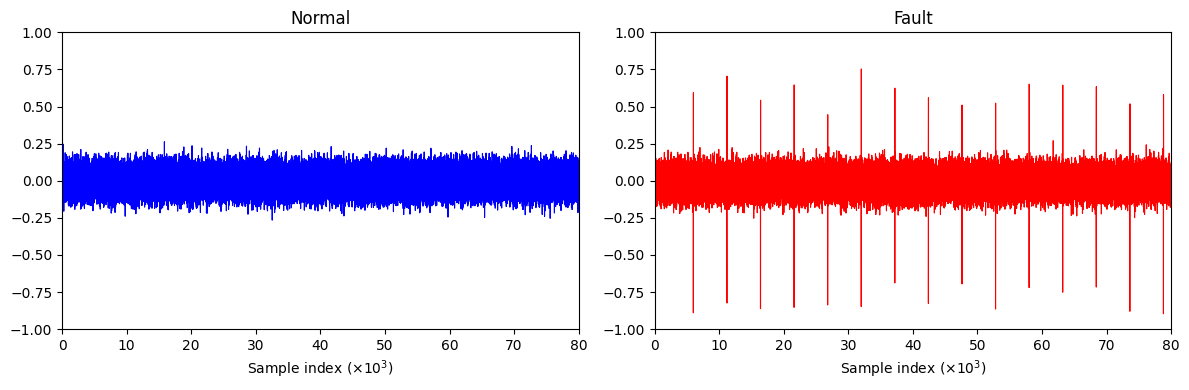


Feature summary
Feature             Normal      Fault
--------------------------------------
RMS                  0.061      0.064
Skewness            -0.004     -0.214
Kurtosis             2.979      9.649
Crest factor         4.320     14.097


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

# ============================================================
# Feature functions
# ============================================================
# Input : x (signal)
# Output: rms, sk (skewness), ku (kurtosis), cf (crest factor)
def calc_features(x):
    rms = np.sqrt(np.mean(x**2))
    sk = skew(x, bias=False)
    ku = kurtosis(x, fisher=False, bias=False)   # Pearson kurtosis
    cf = np.max(np.abs(x)) / rms
    return rms, sk, ku, cf


# ============================================================
# Signal generation
# ============================================================
np.random.seed(42)

N = 80000
t = np.arange(N)

# ----------------------------
# Normal signal
# ----------------------------
normal = 0.06*np.random.randn(N) + 0.015*np.sin(2*np.pi*0.002*t) + 0.010*np.sin(2*np.pi*0.011*t)

# small DC offset to make skewness slightly negative if desired
normal = normal - 0.002

# ----------------------------
# Fault signal
# ----------------------------
fault = 0.06*np.random.randn(N) + 0.015*np.sin(2*np.pi*0.002*t) + 0.010*np.sin(2*np.pi*0.011*t)

# Add periodic impulsive fault components
period = 5200
pulse_positions = np.arange(6000, N-1000, period)

for p in pulse_positions:
    # negative sharp impulse
    fault[p] -= 0.75 + 0.10*np.random.rand()

    # neighboring positive rebound
    if p + 12 < N:
        fault[p + 12] += 0.55 + 0.10*np.random.rand()

    # a small ringing tail
    tail_len = 80
    idx = np.arange(tail_len)
    end_idx = min(p + 13 + tail_len, N)
    valid_len = end_idx - (p + 13)
    if valid_len > 0:
        ring = 0.10*np.exp(-idx[:valid_len]/20.0) * np.sin(2*np.pi*0.12*idx[:valid_len])
        fault[p + 13:end_idx] += ring

# slight negative offset for skewness
fault = fault - 0.01


# ============================================================
# Feature calculation
# ============================================================
rms_n, sk_n, ku_n, cf_n = calc_features(normal)
rms_f, sk_f, ku_f, cf_f = calc_features(fault)

print("Normal")
print(f"RMS       = {rms_n:.3f}")
print(f"Skewness  = {sk_n:.3f}")
print(f"Kurtosis  = {ku_n:.3f}")
print(f"Crest Fac = {cf_n:.3f}")

print("\nFault")
print(f"RMS       = {rms_f:.3f}")
print(f"Skewness  = {sk_f:.3f}")
print(f"Kurtosis  = {ku_f:.3f}")
print(f"Crest Fac = {cf_f:.3f}")


# ============================================================
# Plot signals
# ============================================================
x_axis = np.arange(N) / 1000

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x_axis, normal, 'b', linewidth=0.8)
plt.title('Normal')
plt.xlim(0, N/1000)
plt.ylim(-1, 1)
plt.xlabel(r'Sample index ($\times 10^3$)')

plt.subplot(1, 2, 2)
plt.plot(x_axis, fault, 'r', linewidth=0.8)
plt.title('Fault')
plt.xlim(0, N/1000)
plt.ylim(-1, 1)
plt.xlabel(r'Sample index ($\times 10^3$)')

plt.tight_layout()
plt.show()

# ============================================================
# Print summary table
# ============================================================
print("\nFeature summary")
print(f"{'Feature':<15} {'Normal':>10} {'Fault':>10}")
print("-"*38)
print(f"{'RMS':<15} {rms_n:>10.3f} {rms_f:>10.3f}")
print(f"{'Skewness':<15} {sk_n:>10.3f} {sk_f:>10.3f}")
print(f"{'Kurtosis':<15} {ku_n:>10.3f} {ku_f:>10.3f}")
print(f"{'Crest factor':<15} {cf_n:>10.3f} {cf_f:>10.3f}")

# Bearing features extraction

## Read CWRU bearing data



In [ ]:
# Import modules

import numpy as np
import matplotlib.pyplot as plt
import os
import math
from scipy.io import loadmat
from scipy import io
from scipy.signal import hilbert
from scipy.fft import fft

# Load data
base_path = DATA_ROOT / 'Bearing_CWRU'

normal = io.loadmat(base_path / 'Normal.mat')['x']
outer = io.loadmat(base_path / 'Outer.mat')['x']
inner = io.loadmat(base_path / 'Inner.mat')['x']

case_dict = {
    'Normal': normal,
    'Outer': outer,
    'Inner': inner
}

# ============================================================
# Read bearing geometry / fault-frequency parameters from info.mat
# ============================================================
info = io.loadmat(base_path / 'info.mat')

fr = float(np.squeeze(info['fr']))   # shaft rotational frequency [Hz]
cutoff = 3

# Bearing geometry
D     = float(np.squeeze(info['D']))       # pitch diameter
d_ball = float(np.squeeze(info['d']))      # ball diameter
Nb    = float(np.squeeze(info['Nb']))      # number of balls
alpha = float(np.squeeze(info['alpha']))   # contact angle [rad]

# (calc_bearing_fault_freq is defined in the "Settings and Utilities"
#  section at the top of this notebook)
fault_freqs = calc_bearing_fault_freq(D, d_ball, Nb, alpha, fr)

fs = io.loadmat(base_path / 'Normal.mat')['fs'][0, 0]

print('Bearing fault parameters (computed from info.mat geometry)')
print(f'fr        = {fr:.4f} Hz')
print(f'BPFO      = {fault_freqs[0]:.4f} Hz')
print(f'BPFI      = {fault_freqs[1]:.4f} Hz')
print(f'FTF       = {fault_freqs[2]:.4f} Hz')
print(f'BSF       = {fault_freqs[3]:.4f} Hz (spectrum-ready, already 2x raw formula)')


Bearing fault parameters (computed from info.mat geometry)
fr        = 28.8333 Hz
BPFO      = 103.3610 Hz
BPFI      = 156.1390 Hz
FTF       = 11.4846 Hz
BSF       = 135.9043 Hz (spectrum-ready, already 2x raw formula)


## BPFI/BPFO of CWRU bearing

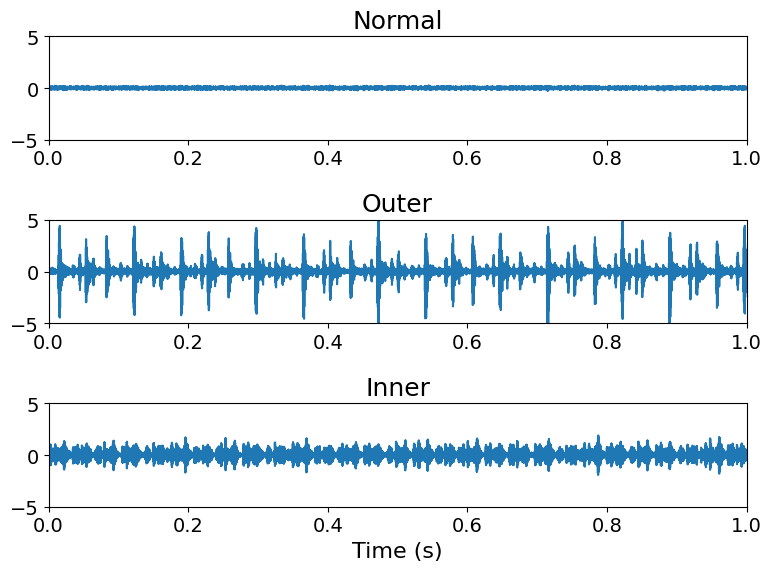

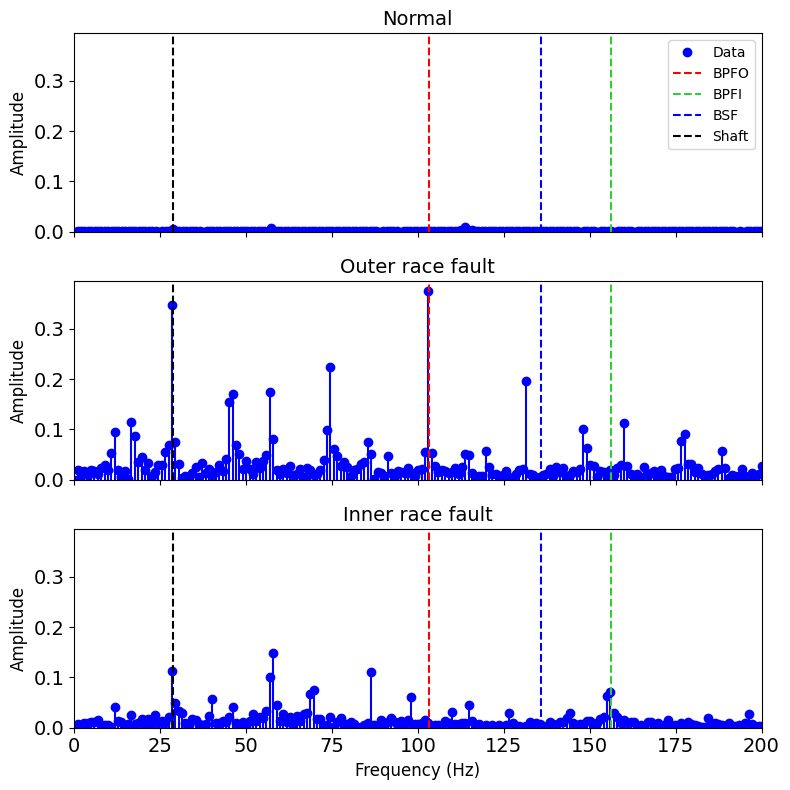

In [ ]:
x1 = normal[:, 0]
x2 = outer[:, 0]
x3 = inner[:, 0]              # Example data for each class

n1 = len(x1)
n2 = len(x2)
n3 = len(x3)

# AR orders below were empirically found by maximizing residual
# kurtosis (aryule with find=0) for each signal individually, then
# fixed here to avoid re-running that search every time. AR order
# needed for adequate whitening varies a lot between signals because
# each one's resonance/impulsive structure is different - it is not
# an arbitrary choice.
# (get_envelope is defined in the "Settings and Utilities" section
#  at the top of this notebook)
xn1 = get_envelope(x1, fs, use_ar=False, use_sk=False, ar_order=8)
xn2 = get_envelope(x2, fs, use_ar=False, use_sk=False, ar_order=445)
xn3 = get_envelope(x3, fs, use_ar=False, use_sk=False, ar_order=557)

X1 = np.abs(fft(xn1))/n1*2
X2 = np.abs(fft(xn2))/n2*2
X3 = np.abs(fft(xn3))/n3*2      # FFT

X1 = X1[0:math.ceil(n1/2)]
X2 = X2[0:math.ceil(n2/2)]
X3 = X3[0:math.ceil(n3/2)]

f1 = np.arange(0,n1)/n1*fs
f2 = np.arange(0,n2)/n2*fs
f3 = np.arange(0,n3)/n3*fs

f1 = f1[0:math.ceil(n1/2)]
f2 = f2[0:math.ceil(n2/2)]
f3 = f3[0:math.ceil(n3/2)]
# plot signals

plt.figure(figsize=(8, 6))

plt.subplot(311)
plt.plot(np.arange(len(x1)) / fs, x1)
plt.title('Normal')
plt.xlim(0, 1)
plt.ylim(-5, 5)

plt.subplot(312)
plt.plot(np.arange(len(x2)) / fs, x2)
plt.title('Outer')
plt.xlim(0, 1)
plt.ylim(-5, 5)

plt.subplot(313)
plt.plot(np.arange(len(x3)) / fs, x3)
plt.title('Inner')
plt.xlim(0, 1)
plt.ylim(-5, 5)
plt.xlabel('Time (s)')

plt.tight_layout()
plt.show()

plt.rc('font', size=10)

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

# Exclude the DC/near-zero bin (f <= 1 Hz) so a large zero-frequency
# value doesn't dominate the y-axis scale.
idx1 = (f1 <= 200) & (f1 > 1)
idx2 = (f2 <= 200) & (f2 > 1)
idx3 = (f3 <= 200) & (f3 > 1)

common_ymax = 1.05 * np.max([
    np.max(X1[idx1]),
    np.max(X2[idx2]),
    np.max(X3[idx3])
])

signals = [
    (f1, X1, 'Normal', common_ymax),
    (f2, X2, 'Outer race fault', common_ymax),
    (f3, X3, 'Inner race fault', common_ymax),
]

for i, (f, X, title, ymax) in enumerate(signals):
    ax = axes[i]

    markerline, stemlines, baseline = ax.stem(
        f, X, linefmt='b-', markerfmt='bo', basefmt=' '
    )
    plt.setp(stemlines, linewidth=1.5)
    plt.setp(markerline, markersize=6)

    l1 = ax.axvline(fault_freqs[0], c='r', ls='--', linewidth=1.5, label='BPFO')
    l2 = ax.axvline(fault_freqs[1], c='limegreen', ls='--', linewidth=1.5, label='BPFI')
    l3 = ax.axvline(fault_freqs[3], c='b', ls='--', linewidth=1.5, label='BSF')
    l4 = ax.axvline(fr, c='k', ls='--', linewidth=1.5, label='Shaft')

    ax.set_xlim(0, 200)
    ax.set_ylim(0, ymax)
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Amplitude', fontsize=12)

    if i == 0:
        ax.legend(
            [markerline, l1, l2, l3, l4],
            ['Data', 'BPFO', 'BPFI', 'BSF', 'Shaft'],
            loc='upper right',
            fontsize=10
        )

axes[-1].set_xlabel('Frequency (Hz)', fontsize=12)

plt.tight_layout()
plt.show()

## Time & domain features CWRU

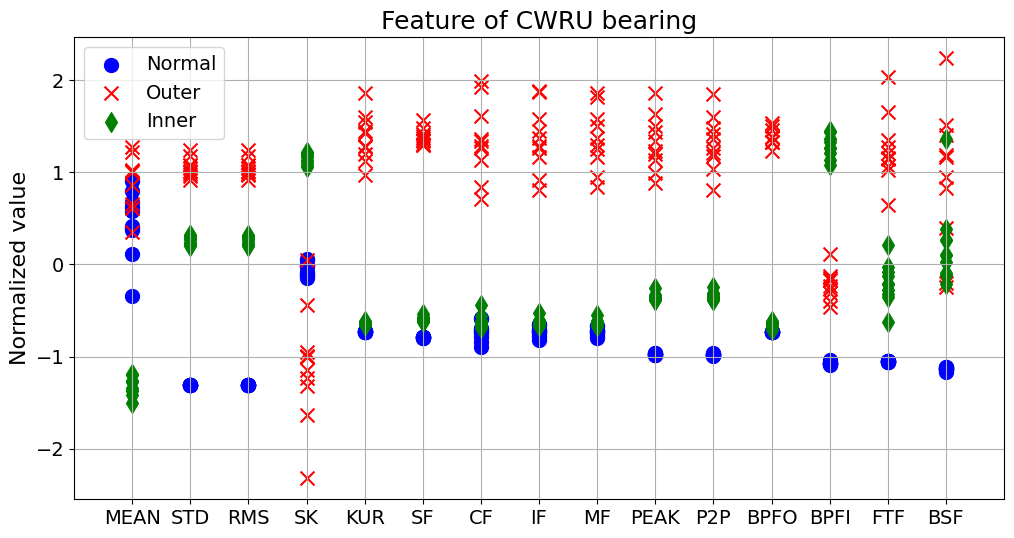

In [ ]:
# Feature extraction

# Normal
features_normal = np.zeros((10,15))
for ix in range(10):
    x = normal[:,ix]
    time_feat, fn_time = timefeature(x)
    # xr = aryule(x, 8, 1)[1]
    bearing_feat, fn_bearing = bear_feat(x, fs, fault_freqs, cutoff) # original xr
    features_normal[ix, :] = np.hstack([time_feat, bearing_feat])

# Outer
features_outer = np.zeros((10,15))
for ix in range(10):
    x = outer[:,ix]
    time_feat, fn_time = timefeature(x)
    # xr = aryule(x, 445, 1)[1]
    bearing_feat, fn_bearing = bear_feat(x, fs, fault_freqs, cutoff) # original xr
    features_outer[ix, :] = np.hstack([time_feat, bearing_feat])

# Inner
features_inner = np.zeros((10,15))
for ix in range(10):
    x = inner[:,ix]
    time_feat, fn_time = timefeature(x)
    # xr = aryule(x, 557, 1)[1]
    bearing_feat, fn_bearing = bear_feat(x, fs, fault_freqs, cutoff) # original xr
    features_inner[ix, :] = np.hstack([time_feat, bearing_feat])
feature_name = fn_time + fn_bearing

# Normalizing
features = np.concatenate([features_normal, features_outer, features_inner], axis=0)
feat_mean = np.mean(features, axis=0); feat_std = np.std(features, ddof=1, axis=0)
features = (features - feat_mean) / feat_std
ix_normal = np.arange(0,10); ix_outer = np.arange(10, 20); ix_inner = np.arange(20,30)

# Features of CWRU bearing
plt.rc('font', size=16)
plt.figure(1, figsize=(12, 6))
for ix in range(len(feature_name)):
    plt.scatter(ix * np.ones(10), features[ix_normal, ix], c='b', marker='o', s=100)
    plt.scatter(ix * np.ones(10), features[ix_outer, ix], c='r', marker='x', s=100)
    plt.scatter(ix * np.ones(10), features[ix_inner, ix], c='g', marker='d', s=100)
plt.xticks(range(len(feature_name)), feature_name); plt.xlim(-1, len(feature_name))
plt.legend(['Normal','Outer','Inner'])
plt.title('Feature of CWRU bearing')
plt.ylabel('Normalized value'); plt.grid()
plt.show()

# Gear features extraction

### Read HS gear data

In [ ]:
# Import modules

import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.io import loadmat

# Load data
file_path = DATA_ROOT / 'Gear_HS' / 'Fault' / 'case_1.mat'
data = loadmat(file_path)
case_label = os.path.basename(os.path.dirname(file_path))

### resample & TSA of HS gear

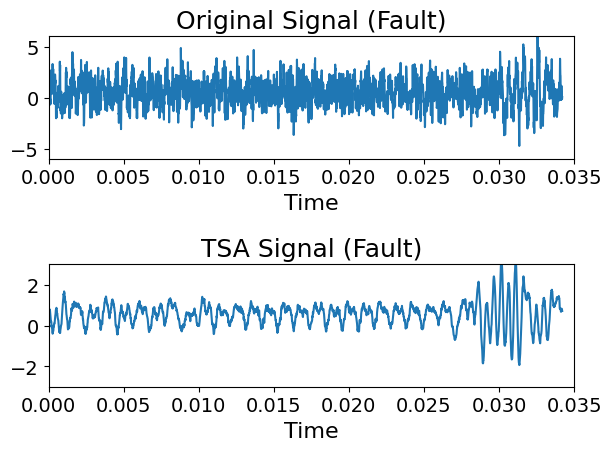

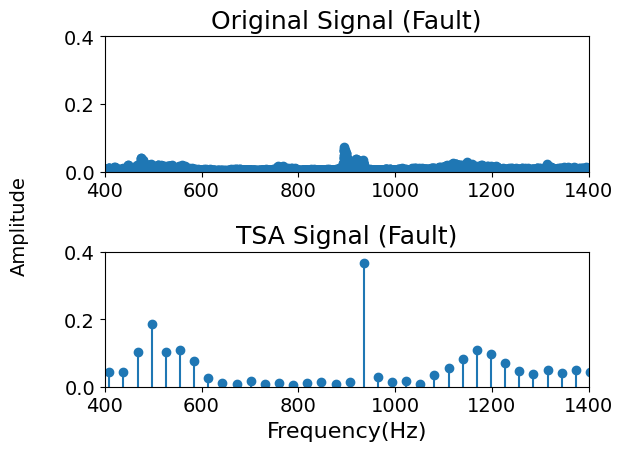

In [ ]:
import math
from scipy.fft import fft
from scipy.interpolate import interp1d

gs = data['gs'].flatten()
ppr = int(data['ppr'].flatten()[0])
sr = int(data['sr'].flatten()[0])
tach = data['tach'].flatten()
teeth = int(data['teeth'].flatten()[0])
x = gs
fs = sr

T = 6
t = np.arange(0, T, 1/fs)

tp = tach[ppr::ppr] - tach[:-ppr:ppr]

xa = sdol_tsa(x, fs, tach, ppr)[0]

n = len(t)
na = len(xa)

plt.figure()
plt.subplot(2, 1, 1)
plt.plot(t[:na], x[:na])
plt.xlabel('Time')
plt.title(f'Original Signal ({case_label})')
plt.ylim([-6, 6])
plt.xlim([0, 0.035])

plt.subplot(2, 1, 2)
plt.plot(t[:na], xa)
plt.xlabel('Time')
plt.title(f'TSA Signal ({case_label})')
plt.ylim([-3, 3])
plt.xlim([0, 0.035])
plt.tight_layout()

f = np.arange(0, n)/n*sr
f = f[0:math.ceil(n/2)]

X = np.abs(fft(x))/n*2
X = X[0:math.ceil(n/2)]

fa = np.arange(0, na)/na*sr
fa = fa[0:math.ceil(na/2)]

Xa = np.abs(fft(xa, axis=0))/na*2;
Xa = Xa[0:math.ceil(na/2)]

fig = plt.figure(2)
plt.subplot(211); plt.stem(f, X, basefmt=" ")
plt.title(f'Original Signal ({case_label})')
plt.xlim(400, 1400)
plt.ylim(0, 0.40)

plt.subplot(212);
plt.stem(fa, Xa, basefmt=" ")
plt.title(f'TSA Signal ({case_label})')
plt.xlim(400, 1400)
plt.ylim(0, 0.40)
plt.xlabel('Frequency(Hz)')
fig.supylabel('Amplitude', size=14)
plt.tight_layout()
plt.show()


## Time features of HS gear

Normal files: ['/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Normal/case_1.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Normal/case_2.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Normal/case_3.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Normal/case_4.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Normal/case_5.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Normal/case_6.mat']
Fault files : ['/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Fault/case_1.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Fault/case_10.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Fault/case_11.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Fault/case_2.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Fault/case_3.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Fault/case_4.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Fault/case_5.mat', '/content/dri

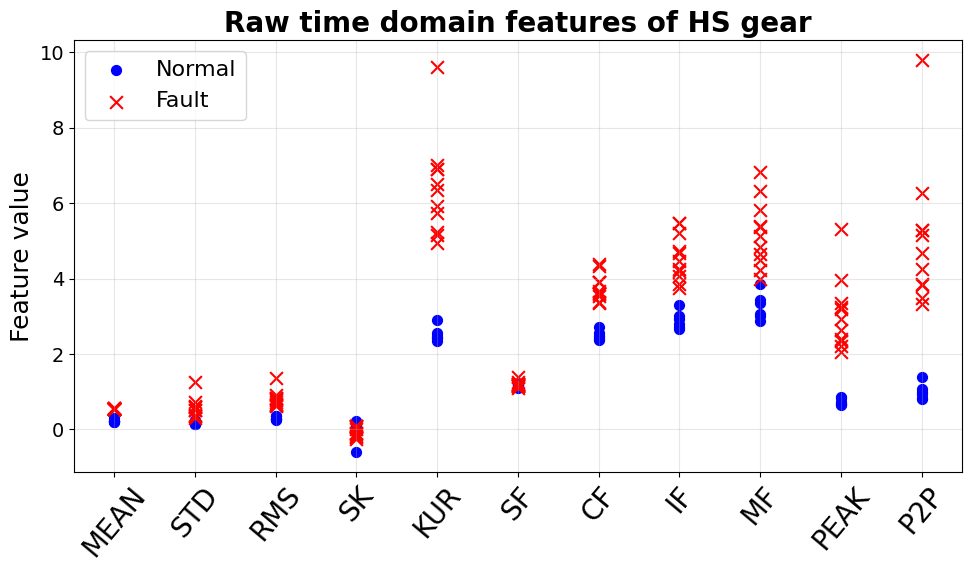

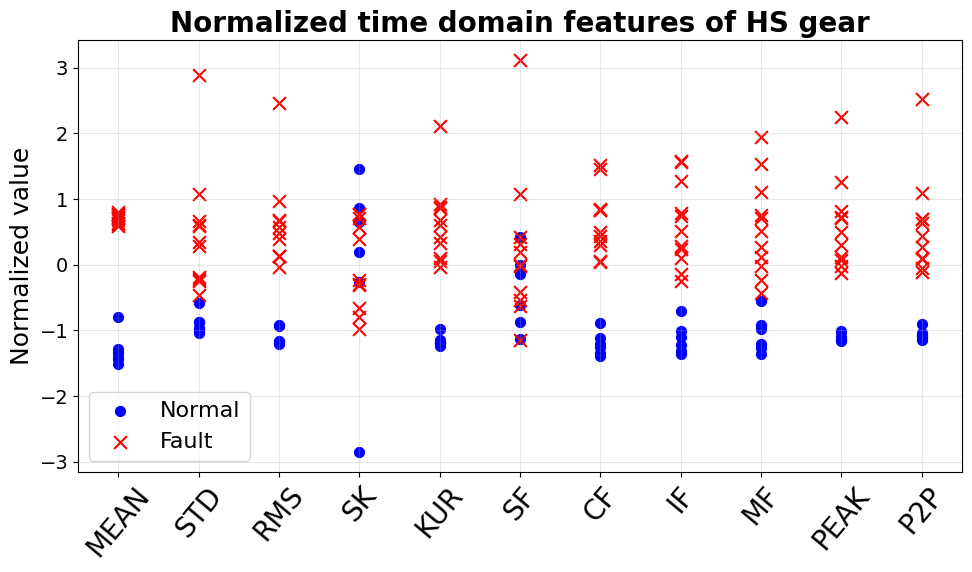

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.stats import skew, kurtosis

# (get_tsa_signal, timefeature, plot_feature_scatter are defined in
#  the "Settings and Utilities" section at the top of this notebook)

# =========================================================
# Collect features from all files
# =========================================================
base_dir = DATA_ROOT / 'Gear_HS'
normal_dir = os.path.join(base_dir, 'Normal')
fault_dir  = os.path.join(base_dir, 'Fault')

normal_files = sorted(glob.glob(os.path.join(normal_dir, 'case_*.mat')))
fault_files  = sorted(glob.glob(os.path.join(fault_dir,  'case_*.mat')))

print('Normal files:', normal_files)
print('Fault files :', fault_files)

normal_features = []
fault_features = []

feature_names = None

# Normal: case_1 ~ 6
for fpath in normal_files:
    xa = get_tsa_signal(fpath)
    feat, feature_names = timefeature(xa)
    normal_features.append(feat)

# Fault: case_1 ~ 11
for fpath in fault_files:
    xa = get_tsa_signal(fpath)
    feat, feature_names = timefeature(xa)
    fault_features.append(feat)

normal_features = np.array(normal_features)   # shape: (6, 11)
fault_features  = np.array(fault_features)    # shape: (11, 11)

print('normal_features shape =', normal_features.shape)
print('fault_features shape  =', fault_features.shape)


# =========================================================
# Normalize feature-wise (z-score over all cases)
# =========================================================
all_features = np.vstack([normal_features, fault_features])   # (17, 11)

feat_mean = np.mean(all_features, axis=0)
feat_std  = np.std(all_features, axis=0, ddof=1)

# avoid divide-by-zero
feat_std[feat_std == 0] = 1.0

normal_features_norm = (normal_features - feat_mean) / feat_std
fault_features_norm  = (fault_features  - feat_mean) / feat_std


# =========================================================
# Plot raw features
# =========================================================
plot_feature_scatter(normal_features, fault_features, feature_names, title_str='Raw time domain features of HS gear', ylabel_str='Feature value')

# =========================================================
# Plot normalized features
# =========================================================
plot_feature_scatter(normal_features_norm, fault_features_norm, feature_names, title_str='Normalized time domain features of HS gear', ylabel_str='Normalized value')

# save time domain features into the name 'td'
normal_td_norm = normal_features_norm.copy()
fault_td_norm  = fault_features_norm.copy()
td_feature_names = feature_names.copy()


## Domain features of HS gear

### order domain plot

max order peak at = 32
max amplitude     = 0.24063201346748772


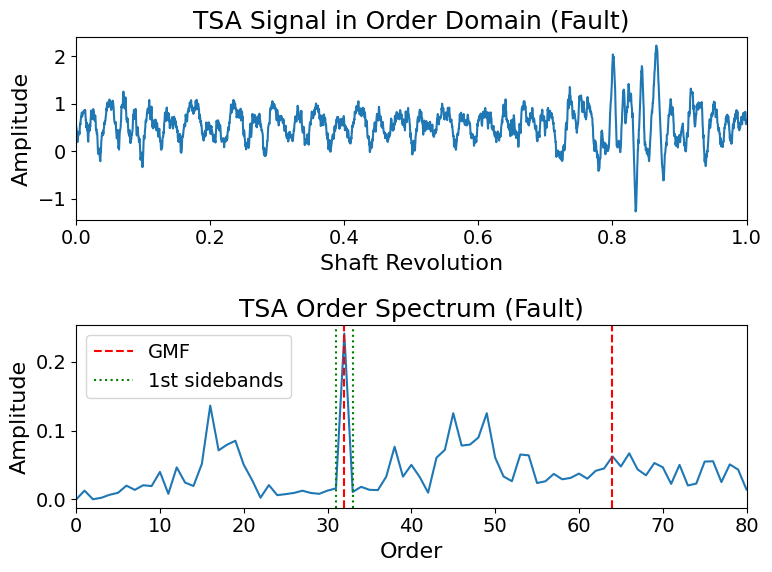

In [ ]:
# =========================================================
# Simple and robust order-domain plot from TSA signal xa
# =========================================================
xa1 = np.asarray(xa).flatten()
na = len(xa1)

# one-revolution TSA waveform
rev_axis = np.linspace(0, 1, na, endpoint=False)

# order spectrum directly from xa
Xa_ord = np.abs(np.fft.rfft(xa1)) * 2 / na
ord_axis = np.arange(len(Xa_ord))   # 0, 1, 2, 3, ...

# optional: remove DC only for display
Xa_ord_plot = Xa_ord.copy()
Xa_ord_plot[0] = 0

print('max order peak at =', ord_axis[np.argmax(Xa_ord_plot)])
print('max amplitude     =', np.max(Xa_ord_plot))

plt.figure(figsize=(8,6))

plt.subplot(2,1,1)
plt.plot(rev_axis, xa1)
plt.xlabel('Shaft Revolution')
plt.ylabel('Amplitude')
plt.title(f'TSA Signal in Order Domain ({case_label})')
plt.xlim([0, 1])

plt.subplot(2,1,2)
plt.plot(ord_axis, Xa_ord_plot)
plt.xlabel('Order')
plt.ylabel('Amplitude')
plt.title(f'TSA Order Spectrum ({case_label})')
plt.xlim([0, 80])

# keep y-axis automatic for now
# plt.ylim([0, 0.4])  # do not use this for now

# reference lines
gmf_order = 32
plt.axvline(gmf_order, color='r', linestyle='--', label='GMF')
plt.axvline(gmf_order - 1, color='g', linestyle=':', label='1st sidebands')
plt.axvline(gmf_order + 1, color='g', linestyle=':')
plt.axvline(2*gmf_order, color='r', linestyle='--')

plt.legend()
plt.tight_layout()
plt.show()

### residual & difference

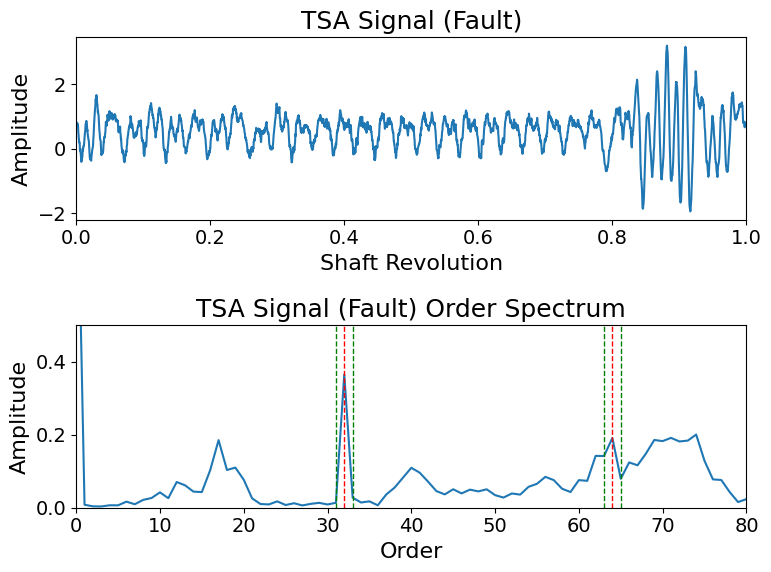

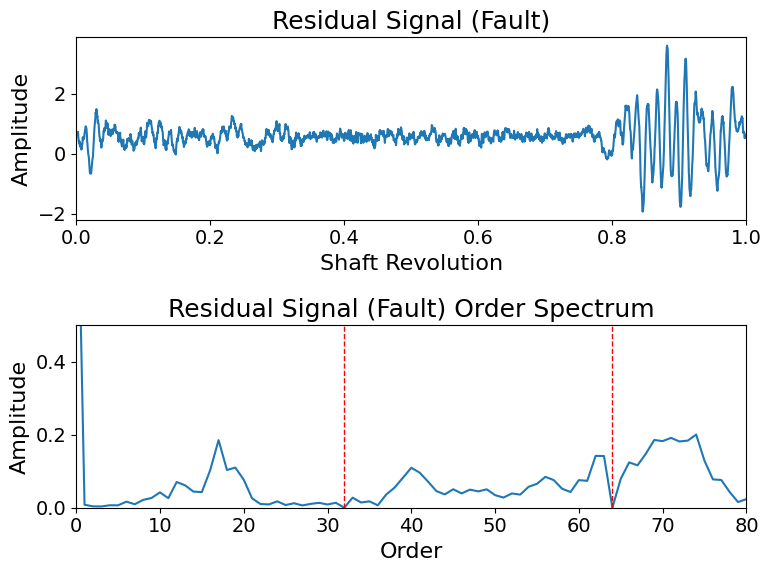

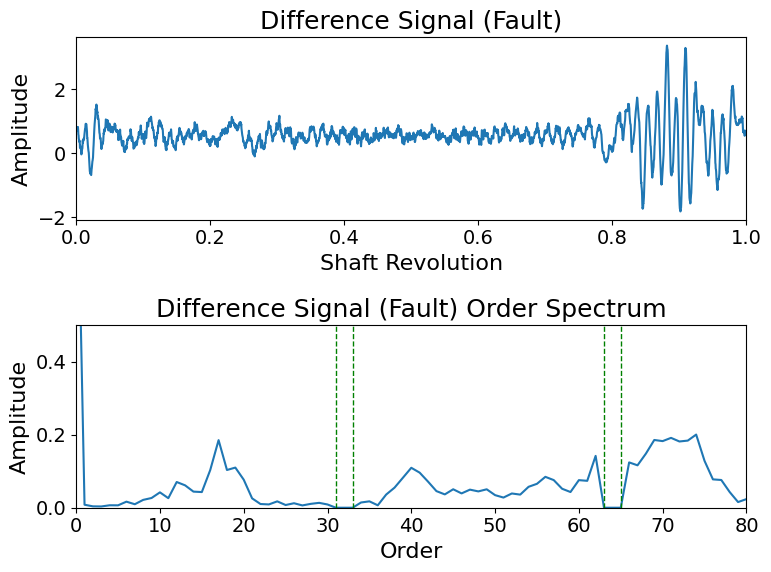

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq

# (calc_order_spectrum, full_order_fft, ifft_real, make_residual_from_tsa,
#  make_difference_from_residual are defined in the "Settings and
#  Utilities" section at the top of this notebook)

# =========================================================
# Load data and get TSA signal
# =========================================================
gs = data['gs'].flatten()
ppr = int(data['ppr'].flatten()[0])
sr = int(data['sr'].flatten()[0])
tach = data['tach'].flatten()
teeth = int(data['teeth'].flatten()[0])

x = gs
fs = sr

xa = sdol_tsa(x, fs, tach, ppr)[0]
xa = np.asarray(xa).flatten()

# =========================================================
# Parameters
# =========================================================
shaft_freq = 30.0
gmf_hz = 960.0
gmf_order = gmf_hz / shaft_freq   # 32 order

n_harm = 5
gmf_half_bw_order = 0.15   # notch half width for GMF harmonics
sb_half_bw_order  = 0.12   # notch half width for first sidebands

# =========================================================
# Compute residual and difference signals
# =========================================================
res = make_residual_from_tsa(xa, gmf_order=gmf_order, n_harm=n_harm, gmf_half_bw_order=gmf_half_bw_order)

diff = make_difference_from_residual(res, gmf_order=gmf_order, n_harm=n_harm, sb_half_bw_order=sb_half_bw_order)

# =========================================================
# Marker lines (section-local: only used by the plot helper below)
# =========================================================
# Input : ax (matplotlib axis), gmf_order, n_harm,
#         show_harmonics (draw red lines at GMF harmonics),
#         show_sidebands (draw green lines at sidebands around
#         each harmonic)
# Output: draws the requested marker lines on ax
def draw_markers(ax, gmf_order=32, n_harm=5, show_harmonics=True, show_sidebands=True):
    if show_harmonics:
        # GMF and its harmonics: red dashed lines
        for h in range(1, n_harm + 1):
            ax.axvline(h * gmf_order, color='r', linestyle='--', linewidth=1)

    if show_sidebands:
        # Left/right sidebands around GMF and each harmonic: green dashed lines
        for h in range(1, n_harm + 1):
            ax.axvline(h * gmf_order - 1, color='g', linestyle='--', linewidth=1)
            ax.axvline(h * gmf_order + 1, color='g', linestyle='--', linewidth=1)

# =========================================================
# Plot helper (section-local)
# =========================================================
# Input : sig, title_str, axis limits, show_harmonics, show_sidebands
# Output: plots the time-domain signal and its order spectrum
def plot_signal_and_order_spectrum(sig, title_str,
                                   time_xlim=(0, 1),
                                   order_xlim=(0, 80),
                                   time_ylim=None,
                                   order_ylim=(0, 0.5),
                                   show_harmonics=True,
                                   show_sidebands=True):
    sig = np.asarray(sig).flatten()
    rev_axis = np.linspace(0, 1, len(sig), endpoint=False)
    order, amp = calc_order_spectrum(sig)

    plt.figure(figsize=(8, 6))

    plt.subplot(2, 1, 1)
    plt.plot(rev_axis, sig)
    plt.title(title_str)
    plt.xlabel('Shaft Revolution')
    plt.ylabel('Amplitude')
    plt.xlim(time_xlim)
    if time_ylim is not None:
        plt.ylim(time_ylim)

    ax = plt.subplot(2, 1, 2)
    plt.plot(order, amp)
    plt.title(f'{title_str} Order Spectrum')
    plt.xlabel('Order')
    plt.ylabel('Amplitude')
    plt.xlim(order_xlim)
    plt.ylim(order_ylim)

    draw_markers(ax, gmf_order=gmf_order, n_harm=n_harm,
                 show_harmonics=show_harmonics, show_sidebands=show_sidebands)

    plt.tight_layout()
    plt.show()

# =========================================================
# Plot TSA / Residual / Difference
# =========================================================
# TSA: show both GMF harmonics and sidebands (contains everything)
plot_signal_and_order_spectrum(xa, title_str=f'TSA Signal ({case_label})', order_xlim=(0, 80), order_ylim=(0, 0.5))

# Residual: only GMF harmonics (red) - sidebands not yet removed at this stage
plot_signal_and_order_spectrum(res, title_str=f'Residual Signal ({case_label})', order_xlim=(0, 80), order_ylim=(0, 0.5),
                                show_harmonics=True, show_sidebands=False)

# Difference: only sidebands (green) - these are what get removed at this stage
plot_signal_and_order_spectrum(diff, title_str=f'Difference Signal ({case_label})', order_xlim=(0, 80), order_ylim=(0, 0.5),
                                show_harmonics=False, show_sidebands=True)

### domain features of HS gear

Normal files: ['/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Normal/case_1.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Normal/case_2.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Normal/case_3.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Normal/case_4.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Normal/case_5.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Normal/case_6.mat']
Fault files : ['/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Fault/case_1.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Fault/case_10.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Fault/case_11.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Fault/case_2.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Fault/case_3.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Fault/case_4.mat', '/content/drive/MyDrive/PHM Practice/Datasets/Gear_HS/Fault/case_5.mat', '/content/dri

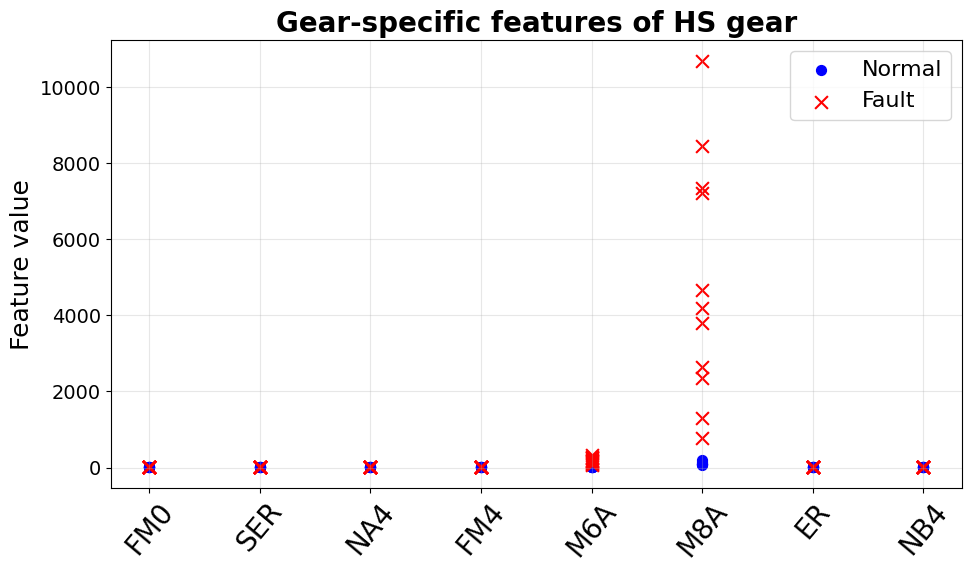

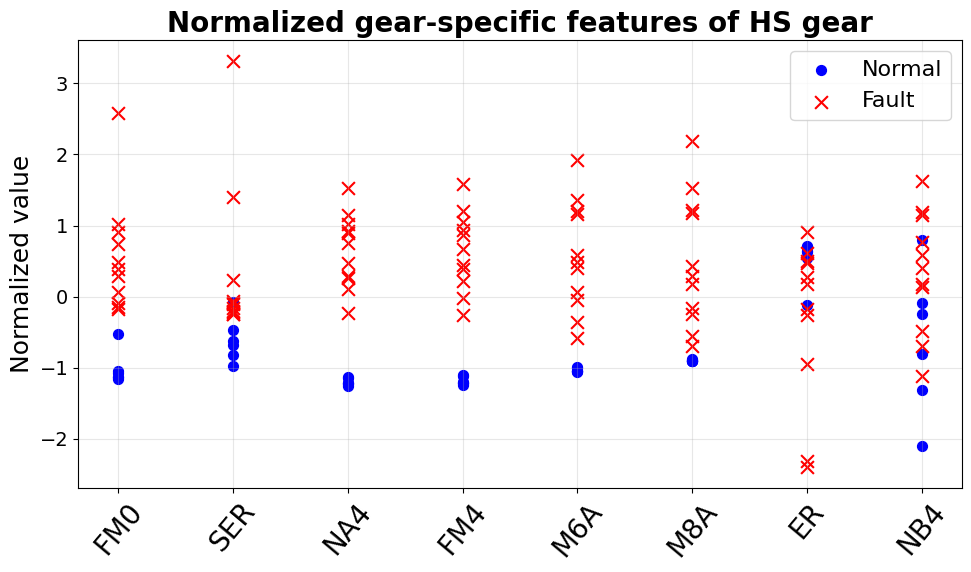

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.fft import fft, ifft, fftfreq

# =========================================================
# Paths
# =========================================================
base_dir = DATA_ROOT / 'Gear_HS'
normal_dir = os.path.join(base_dir, 'Normal')
fault_dir  = os.path.join(base_dir, 'Fault')

normal_files = sorted(glob.glob(os.path.join(normal_dir, 'case_*.mat')))
fault_files  = sorted(glob.glob(os.path.join(fault_dir,  'case_*.mat')))

print('Normal files:', normal_files)
print('Fault files :', fault_files)

# =========================================================
# Parameters
# =========================================================
shaft_freq = 30.0
gmf_hz = 960.0
gmf_order = gmf_hz / shaft_freq   # 32 order

n_harm = 5
gmf_half_bw_order = 0.15
sb_half_bw_order  = 0.12

# =========================================================
# TSA / Residual / Difference / BPF
# (calc_order_spectrum, full_order_fft, ifft_real, get_tsa_signal,
#  make_residual_from_tsa, make_difference_from_residual are already
#  defined earlier in this notebook - reused here as-is.)
# =========================================================
def make_bpf_from_tsa(xa, gmf_order=32, n_harm=5,
                      gmf_half_bw_order=0.15, sb_half_bw_order=0.12):
    """
    Keep GMF harmonics and their 1st sidebands only.
    """
    order_full, X_full = full_order_fft(xa)
    X_bpf = np.zeros_like(X_full, dtype=complex)
    abs_order = np.abs(order_full)

    for h in range(1, n_harm + 1):
        center = h * gmf_order

        # GMF harmonic
        gmf_band = np.abs(abs_order - center) <= gmf_half_bw_order
        X_bpf[gmf_band] = X_full[gmf_band]

        # 1st sideband pair
        sb1 = center - 1
        sb2 = center + 1

        sb1_band = np.abs(abs_order - sb1) <= sb_half_bw_order
        sb2_band = np.abs(abs_order - sb2) <= sb_half_bw_order

        X_bpf[sb1_band] = X_full[sb1_band]
        X_bpf[sb2_band] = X_full[sb2_band]

    bpf_sig = ifft_real(X_bpf)
    return bpf_sig

# =========================================================
# Gear-specific feature definitions
# =========================================================
# Input : x (signal), order (moment order)
# Output: standardized statistical moment of x at the given order
def standardized_moment(x, order):
    x = np.asarray(x).flatten()
    mu = np.mean(x)
    sigma = np.std(x, ddof=1)
    if sigma == 0:
        return 0.0
    return np.mean((x - mu) ** order) / (sigma ** order)

# Input : order_axis, amp (order spectrum), centers (list), half_bw
# Output: sum of spectrum amplitude within the given bands
def band_amplitude_sum(order_axis, amp, centers, half_bw):
    s = 0.0
    for c in centers:
        band = np.abs(order_axis - c) <= half_bw
        s += np.sum(amp[band])
    return s

# Input : xa, res, diff, bpf (processed signals), gmf_order, n_harm, bandwidths
# Output: feature (FM0, SER, NA4, FM4, M6A, M8A, ER, NB4), feature_name
def gear_specific_features(xa, res, diff, bpf,
                           gmf_order=32, n_harm=5,
                           gmf_half_bw_order=0.15,
                           sb_half_bw_order=0.12):

    order_axis, amp = calc_order_spectrum(xa)

    gmf_centers = [h * gmf_order for h in range(1, n_harm + 1)]
    sb_centers = []
    for h in range(1, n_harm + 1):
        c = h * gmf_order
        sb_centers.extend([c - 1, c + 1])

    mesh_sum = band_amplitude_sum(order_axis, amp, gmf_centers, gmf_half_bw_order)
    sideband_sum = band_amplitude_sum(order_axis, amp, sb_centers, sb_half_bw_order)

    pp_xa = np.max(xa) - np.min(xa)

    # FM0
    fm0 = pp_xa / mesh_sum if mesh_sum != 0 else 0.0

    # SER
    ser = sideband_sum / mesh_sum if mesh_sum != 0 else 0.0

    # NA4
    na4 = standardized_moment(res, 4)

    # FM4
    fm4 = standardized_moment(diff, 4)

    # M6A
    m6a = standardized_moment(diff, 6)

    # M8A
    m8a = standardized_moment(diff, 8)

    # ER
    er = np.sum(diff**2) / np.sum(res**2) if np.sum(res**2) != 0 else 0.0

    # NB4
    nb4 = standardized_moment(bpf, 4)

    feature = np.array([fm0, ser, na4, fm4, m6a, m8a, er, nb4], dtype=float)
    feature_name = ['FM0', 'SER', 'NA4', 'FM4', 'M6A', 'M8A', 'ER', 'NB4']
    return feature, feature_name

# =========================================================
# Extract features from all files
# =========================================================
normal_features = []
fault_features = []
feature_names = None

for fpath in normal_files:
    xa = get_tsa_signal(fpath)
    res = make_residual_from_tsa(xa, gmf_order=gmf_order, n_harm=n_harm, gmf_half_bw_order=gmf_half_bw_order)
    diff = make_difference_from_residual(res, gmf_order=gmf_order, n_harm=n_harm, sb_half_bw_order=sb_half_bw_order)
    bpf = make_bpf_from_tsa(xa, gmf_order=gmf_order, n_harm=n_harm, gmf_half_bw_order=gmf_half_bw_order, sb_half_bw_order=sb_half_bw_order)

    feat, feature_names = gear_specific_features(xa, res, diff, bpf, gmf_order=gmf_order, n_harm=n_harm, gmf_half_bw_order=gmf_half_bw_order, sb_half_bw_order=sb_half_bw_order)
    normal_features.append(feat)

for fpath in fault_files:
    xa = get_tsa_signal(fpath)
    res = make_residual_from_tsa(xa, gmf_order=gmf_order, n_harm=n_harm, gmf_half_bw_order=gmf_half_bw_order)
    diff = make_difference_from_residual(res, gmf_order=gmf_order, n_harm=n_harm, sb_half_bw_order=sb_half_bw_order)
    bpf = make_bpf_from_tsa(xa, gmf_order=gmf_order, n_harm=n_harm, gmf_half_bw_order=gmf_half_bw_order, sb_half_bw_order=sb_half_bw_order)

    feat, feature_names = gear_specific_features(xa, res, diff, bpf, gmf_order=gmf_order, n_harm=n_harm, gmf_half_bw_order=gmf_half_bw_order, sb_half_bw_order=sb_half_bw_order)
    fault_features.append(feat)

normal_features = np.array(normal_features)   # (6, 8)
fault_features  = np.array(fault_features)    # (11, 8)

print('normal_features shape =', normal_features.shape)
print('fault_features shape  =', fault_features.shape)

# =========================================================
# Normalize feature-wise (z-score)
# =========================================================
all_features = np.vstack([normal_features, fault_features])

feat_mean = np.mean(all_features, axis=0)
feat_std  = np.std(all_features, axis=0, ddof=1)
feat_std[feat_std == 0] = 1.0

normal_features_norm = (normal_features - feat_mean) / feat_std
fault_features_norm  = (fault_features  - feat_mean) / feat_std

# =========================================================
# Raw plot
# (plot_feature_scatter already defined earlier in this notebook)
# =========================================================
plot_feature_scatter(normal_features, fault_features, feature_names, title_str='Gear-specific features of HS gear', ylabel_str='Feature value')

# =========================================================
# Normalized plot
# =========================================================
plot_feature_scatter(normal_features_norm, fault_features_norm, feature_names, title_str='Normalized gear-specific features of HS gear', ylabel_str='Normalized value')

# save gear specific features into the name 'gs'
normal_gs_norm = normal_features_norm.copy()
fault_gs_norm  = fault_features_norm.copy()
gs_feature_names = feature_names.copy()


# Feature selection: Diagnosis

## feature selection of HS gear

normal_all shape = (6, 19)
fault_all shape  = (11, 19)
No. of features  = 19

Best 3 features:
1. MEAN  FDR = 57.028522
2. NA4  FDR = 12.764543
3. CF  FDR = 12.130535

Worst 3 features:
1. SK  FDR = 0.000046
2. SF  FDR = 0.227415
3. ER  FDR = 0.461820


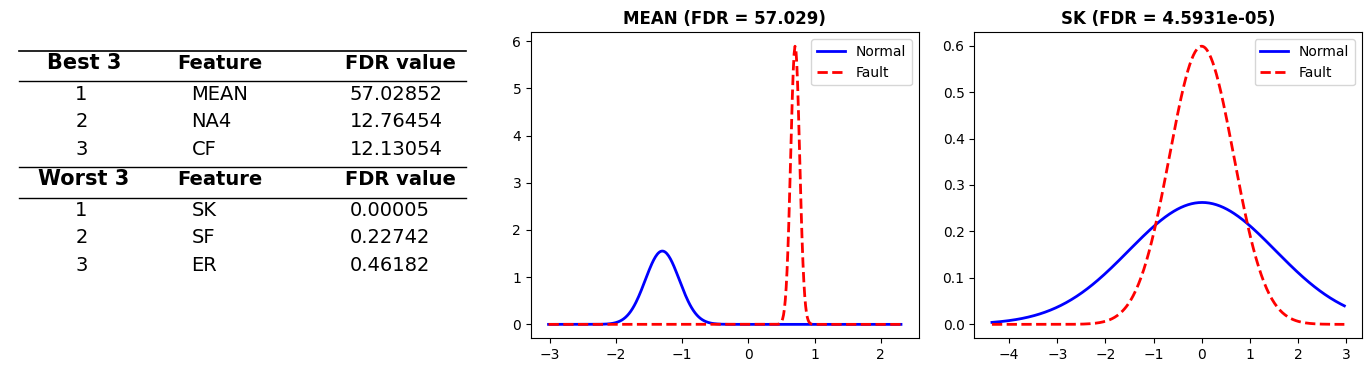

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# =========================================================
# Combine 21 normalized features
# =========================================================
normal_all = np.hstack([normal_td_norm, normal_gs_norm])   # (6, 21)
fault_all  = np.hstack([fault_td_norm,  fault_gs_norm])    # (11, 21)

all_feature_names = td_feature_names + gs_feature_names

print('normal_all shape =', normal_all.shape)
print('fault_all shape  =', fault_all.shape)
print('No. of features  =', len(all_feature_names))

# =========================================================
# Fisher Discriminant Ratio
#    FDR = (mu_n - mu_f)^2 / (var_n + var_f)
# =========================================================
mu_n = np.mean(normal_all, axis=0)
mu_f = np.mean(fault_all, axis=0)

var_n = np.var(normal_all, axis=0, ddof=1)
var_f = np.var(fault_all, axis=0, ddof=1)

eps = 1e-12
fdr = (mu_n - mu_f)**2 / (var_n + var_f + eps)

# sort
idx_best = np.argsort(fdr)[::-1]
idx_worst = np.argsort(fdr)

best3_idx = idx_best[:3]
worst3_idx = idx_worst[:3]

print('\nBest 3 features:')
for i, idx in enumerate(best3_idx, 1):
    print(f'{i}. {all_feature_names[idx]}  FDR = {fdr[idx]:.6f}')

print('\nWorst 3 features:')
for i, idx in enumerate(worst3_idx, 1):
    print(f'{i}. {all_feature_names[idx]}  FDR = {fdr[idx]:.6f}')

# =========================================================
# Plot helper for Gaussian-like curves
# =========================================================
# Input : x (data), title_str
# Output: plots histogram of x overlaid with a fitted Gaussian curve
def plot_gaussian_like(ax, normal_vals, fault_vals, feat_name, feat_fdr):
    mu1 = np.mean(normal_vals)
    mu2 = np.mean(fault_vals)
    sd1 = np.std(normal_vals, ddof=1)
    sd2 = np.std(fault_vals, ddof=1)

    if sd1 == 0:
        sd1 = 1e-6
    if sd2 == 0:
        sd2 = 1e-6

    xmin = min(np.min(normal_vals), np.min(fault_vals)) - 1.5
    xmax = max(np.max(normal_vals), np.max(fault_vals)) + 1.5
    xx = np.linspace(xmin, xmax, 400)

    y1 = norm.pdf(xx, mu1, sd1)
    y2 = norm.pdf(xx, mu2, sd2)

    ax.plot(xx, y1, 'b-', linewidth=2, label='Normal')
    ax.plot(xx, y2, 'r--', linewidth=2, label='Fault')
    ax.set_title(f'{feat_name.upper()} (FDR = {feat_fdr:.5g})', fontsize=12, weight='bold')
    ax.legend(fontsize=10)
    ax.tick_params(labelsize=10)

# =========================================================
# Figure: Best 3 / Worst 3 table + best1/worst1 Gaussian
# =========================================================
best1 = best3_idx[0]
worst1 = worst3_idx[0]

fig = plt.figure(figsize=(14, 4))
gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 1, 1])

# ---- left: table-like text ----
ax0 = fig.add_subplot(gs[0, 0])
ax0.axis('off')

# horizontal lines
ax0.plot([0.02, 0.98], [0.94, 0.94], color='k', lw=1.2, transform=ax0.transAxes)
ax0.plot([0.02, 0.98], [0.84, 0.84], color='k', lw=1.0, transform=ax0.transAxes)
ax0.plot([0.02, 0.98], [0.56, 0.56], color='k', lw=1.0, transform=ax0.transAxes)
ax0.plot([0.02, 0.98], [0.46, 0.46], color='k', lw=1.0, transform=ax0.transAxes)

# Best 3 header
ax0.text(0.08, 0.88, 'Best 3', fontsize=15, weight='bold', transform=ax0.transAxes)
ax0.text(0.36, 0.88, 'Feature', fontsize=14, weight='bold', transform=ax0.transAxes)
ax0.text(0.72, 0.88, 'FDR value', fontsize=14, weight='bold', transform=ax0.transAxes)

for row, idx in enumerate(best3_idx):
    y = 0.78 - 0.09 * row
    ax0.text(0.14, y, f'{row+1}', fontsize=14, transform=ax0.transAxes)
    ax0.text(0.39, y, f'{all_feature_names[idx]}', fontsize=14, transform=ax0.transAxes)
    ax0.text(0.73, y, f'{fdr[idx]:.5f}', fontsize=14, transform=ax0.transAxes)

# Worst 3 header
ax0.text(0.06, 0.50, 'Worst 3', fontsize=15, weight='bold', transform=ax0.transAxes)
ax0.text(0.36, 0.50, 'Feature', fontsize=14, weight='bold', transform=ax0.transAxes)
ax0.text(0.72, 0.50, 'FDR value', fontsize=14, weight='bold', transform=ax0.transAxes)

for row, idx in enumerate(worst3_idx):
    y = 0.40 - 0.09 * row
    ax0.text(0.14, y, f'{row+1}', fontsize=14, transform=ax0.transAxes)
    ax0.text(0.39, y, f'{all_feature_names[idx]}', fontsize=14, transform=ax0.transAxes)
    ax0.text(0.73, y, f'{fdr[idx]:.5f}', fontsize=14, transform=ax0.transAxes)

# ---- middle: best feature Gaussian ----
ax1 = fig.add_subplot(gs[0, 1])
plot_gaussian_like(ax1, normal_all[:, best1], fault_all[:, best1], all_feature_names[best1], fdr[best1])

# ---- right: worst feature Gaussian ----
ax2 = fig.add_subplot(gs[0, 2])
plot_gaussian_like(ax2, normal_all[:, worst1], fault_all[:, worst1], all_feature_names[worst1], fdr[worst1])

plt.tight_layout()
plt.show()

## feature selection of CWRU


Top 3 feature combinations
 Rank Feature combination J3 value
    1              SK, SF 751.4039
    2           STD, BPFO 626.5616
    3           RMS, BPFO 624.7494

Bottom 3 feature combinations
 Rank Feature combination J3 value
    1           MEAN, BSF  16.5741
    2             SK, BSF  17.4299
    3             CF, BSF  17.7169


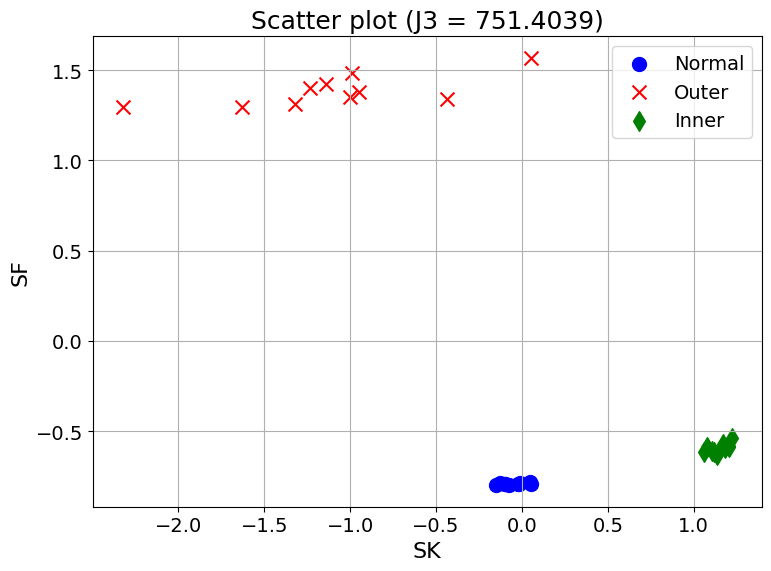

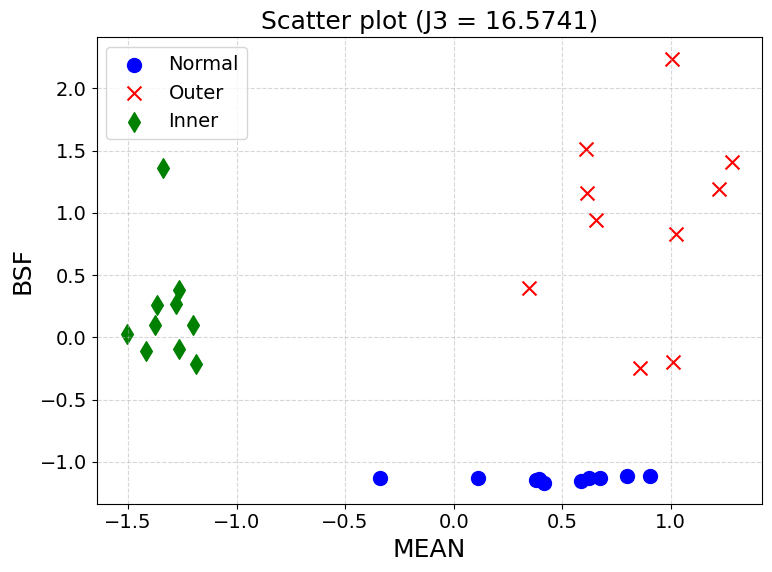

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

# =========================================================================
# This code is programmed by Seokgoo Kim in 2018
# Revised for NumPy 2.0 compatibility
# ============================= Input =====================================
# data (N x M)   : N samples of M features
# label (N,)     : Labels of N samples
# ============================= Output ====================================
# J3 : Calculated J3 value
# =========================================================================
def ScattMat(data, label):
    data = np.asarray(data, dtype=float)
    label = np.asarray(label)
    class_ = pd.unique(label)
    M = len(class_)
    N = len(label)

    if data.shape[0] != len(label):
        data = data.T

    sw = np.zeros((data.shape[1], data.shape[1]), dtype=float)
    sb = np.zeros((data.shape[1], data.shape[1]), dtype=float)

    mu = np.mean(data, axis=0).reshape(-1, 1)   # global mean vector (column)

    for i in range(M):
        temp = data[label == class_[i]]
        mu_i = np.mean(temp, axis=0).reshape(-1, 1)

        # within-class scatter
        Xc = temp - mu_i.ravel()
        s = (Xc.T @ Xc) / (len(temp) - 1)
        sw = sw + (len(temp) / N) * s

        # between-class scatter
        d = mu_i - mu
        sb = sb + (len(temp) / N) * (d @ d.T)

    sm = sw + sb
    J3 = np.trace(np.linalg.pinv(sw) @ sm)

    return float(J3)


# =========================================================================
# Scatter matrix (J3)
# =========================================================================
tmp = np.array(list(combinations(np.arange(len(feature_name)), 2)))
lab = np.hstack([np.zeros(10), np.ones(10), np.ones(10) * 2])

features_std = (features - np.mean(features, axis=0)) / np.std(features, axis=0, ddof=1)
features = features_std

J3 = np.zeros(len(tmp))

for k in range(len(tmp)):
    pair_data = np.c_[features[:, tmp[k, 0]], features[:, tmp[k, 1]]]
    J3[k] = ScattMat(pair_data, lab)

# sort index in descending order
sort_idx = np.argsort(J3)[::-1]

# sorted J3
J3_sorted = J3[sort_idx]

# =========================================================================
# Best 3
# =========================================================================
top_rows = []
for rank in range(3):
    idx = sort_idx[rank]
    feat1 = feature_name[tmp[idx, 0]]
    feat2 = feature_name[tmp[idx, 1]]
    jval = J3[idx]
    top_rows.append([rank + 1, f'{feat1}, {feat2}', jval])

T1 = pd.DataFrame(top_rows, columns=['Rank', 'Feature combination', 'J3 value'])

# =========================================================================
# Worst 3
# =========================================================================
bottom_rows = []
for rank in range(3):
    idx = sort_idx[-(rank + 1)]
    feat1 = feature_name[tmp[idx, 0]]
    feat2 = feature_name[tmp[idx, 1]]
    jval = J3[idx]
    bottom_rows.append([rank + 1, f'{feat1}, {feat2}', jval])

T2 = pd.DataFrame(bottom_rows, columns=['Rank', 'Feature combination', 'J3 value'])

# optional: number formatting
T1['J3 value'] = T1['J3 value'].map(lambda x: f'{x:.4f}')
T2['J3 value'] = T2['J3 value'].map(lambda x: f'{x:.4f}')

print('\nTop 3 feature combinations')
print(T1.to_string(index=False))

print('\nBottom 3 feature combinations')
print(T2.to_string(index=False))

# =========================================================================
# Scatter plot for a high-J3 feature pair
# =========================================================================
rank_to_plot = 0              # 0: best, 1: 2nd best, 2: 3rd best
idx = sort_idx[rank_to_plot]  # actual pair index

f1_idx = tmp[idx, 0]
f2_idx = tmp[idx, 1]

plt.figure(figsize=(8, 6))
plt.scatter(features[ix_normal, f1_idx], features[ix_normal, f2_idx],
            c='b', marker='o', s=100, label='Normal')
plt.scatter(features[ix_outer,  f1_idx], features[ix_outer,  f2_idx],
            c='r', marker='x', s=100, label='Outer')
plt.scatter(features[ix_inner,  f1_idx], features[ix_inner,  f2_idx],
            c='g', marker='d', s=100, label='Inner')

plt.xlabel(feature_name[f1_idx])
plt.ylabel(feature_name[f2_idx])
plt.title(f'Scatter plot (J3 = {J3[idx]:.4f})')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================================
# Scatter plot for a low-J3 feature pair (worst)
# =========================================================================
worst_rank = 0     # 0: worst, 1: 2nd worst, 2: 3rd worst
idx = sort_idx[-(worst_rank + 1)]

f1_idx = tmp[idx, 0]
f2_idx = tmp[idx, 1]

plt.figure(figsize=(8, 6))
plt.scatter(features[ix_normal, f1_idx], features[ix_normal, f2_idx],
            c='b', marker='o', s=100, label='Normal')
plt.scatter(features[ix_outer,  f1_idx], features[ix_outer,  f2_idx],
            c='r', marker='x', s=100, label='Outer')
plt.scatter(features[ix_inner,  f1_idx], features[ix_inner,  f2_idx],
            c='g', marker='d', s=100, label='Inner')

plt.xlabel(feature_name[f1_idx], fontsize=18)
plt.ylabel(feature_name[f2_idx], fontsize=18)
plt.title(f'Scatter plot (J3 = {J3[idx]:.4f})', fontsize=18)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# Feature selection: Prognosis

### Read IMS bearing data

In [3]:
import gc
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# ============================================================
# File paths
# ============================================================
base_path = DATA_ROOT / 'Bearing_IMS'

file_paths = {
    'IMS_2nd_ch1': base_path / 'IMS_2nd_ch1.mat',
    'IMS_1st_ch5': base_path / 'IMS_1st_ch5.mat',
    'IMS_3rd_ch3': base_path / 'IMS_3rd_ch3.mat'
}

# ============================================================
# Read bearing geometry / fault-frequency parameters from info.mat
#     (all IMS test sets use the same bearing model, so one info.mat
#     applies to IMS_1st_ch5, IMS_2nd_ch1, and IMS_3rd_ch3 alike)
# ============================================================
info = loadmat(base_path / 'info.mat')

fs = float(np.squeeze(info['fs']))   # sampling frequency [Hz]
sn = int(np.squeeze(info['sn']))     # samples per cycle
fr = float(np.squeeze(info['fr']))   # shaft rotational frequency [Hz]

# Bearing geometry
D     = float(np.squeeze(info['D']))       # pitch diameter
d_ball = float(np.squeeze(info['d']))      # ball diameter
Nb    = float(np.squeeze(info['Nb']))      # number of balls
alpha = float(np.squeeze(info['alpha']))   # contact angle [rad]

# (calc_bearing_fault_freq is defined in the "Settings and Utilities"
#  section at the top of this notebook)
fault_freqs = calc_bearing_fault_freq(D, d_ball, Nb, alpha, fr)

cutoff = 10   # frequency tolerance used by bear_feat()

print('Bearing fault parameters (computed from info.mat geometry)')
print(f'fr        = {fr:.4f} Hz')
print(f'BPFO      = {fault_freqs[0]:.4f} Hz')
print(f'BPFI      = {fault_freqs[1]:.4f} Hz')
print(f'FTF       = {fault_freqs[2]:.4f} Hz')
print(f'BSF       = {fault_freqs[3]:.4f} Hz (spectrum-ready, already 2x raw formula)')

# ============================================================
# Helper: load one dataset (used both for the "plot all" loop
#    below and for the single dataset selected in step 4)
# ============================================================
# Input : dataset_name (e.g. 'IMS_2nd_ch1')
# Output: x (cycles as columns, last 5 cycles removed)
def load_ims_dataset(dataset_name):
    data = loadmat(file_paths[dataset_name], variable_names=[dataset_name])
    x = data[dataset_name]
    x = x[:, :-5]   # remove the last five cycles
    return x

# ============================================================
# Load, plot, and release each dataset
#    Set plot_all_datasets = False to skip this and jump straight
#    to loading only the one dataset selected in step 4.
# ============================================================
plot_all_datasets = False

if plot_all_datasets:
    for dataset_name in file_paths:

        print(f'\nLoading {dataset_name} ...')

        x = load_ims_dataset(dataset_name)
        n_cycle = x.shape[1]

        print(f'Cycles after removal = {n_cycle}')

        # ----------------------------------------------------
        # Cycle-wise minimum and maximum
        # This preserves transient peaks without plotting
        # hundreds of millions of individual points.
        # ----------------------------------------------------
        sig_min = np.min(x, axis=0)
        sig_max = np.max(x, axis=0)
        cycle = np.arange(1, n_cycle + 1)

        plt.figure(figsize=(12, 3.5))
        plt.fill_between(cycle, sig_min, sig_max, color='tab:blue', alpha=0.8, linewidth=0)

        plt.xlabel('Cycle')
        plt.ylabel('Acceleration')
        plt.title(f'Run-to-Failure Signal: {dataset_name}')
        plt.xlim(1, n_cycle)
        plt.ylim(-5, 5)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        plt.close('all')

        # ----------------------------------------------------
        # Release the current dataset from RAM
        # ----------------------------------------------------
        del x, sig_min, sig_max, cycle
        gc.collect()

        print(f'{dataset_name} released from memory.')

# ============================================================
# Select and load only one dataset for subsequent analysis
# ============================================================
# var_name = 'IMS_2nd_ch1'
var_name = 'IMS_1st_ch5'
# var_name = 'IMS_3rd_ch3'

xall = load_ims_dataset(var_name)
gc.collect()

print('\nSelected dataset')
print('Variable name =', var_name)
print('Data shape =', xall.shape)
print(f'Memory usage = {xall.nbytes / 1024**3:.2f} GB')


Bearing fault parameters (computed from info.mat geometry)
fr        = 33.3333 Hz
BPFO      = 236.4035 Hz
BPFI      = 296.9299 Hz
FTF       = 14.7752 Hz
BSF       = 279.8333 Hz (spectrum-ready, already 2x raw formula)

Selected dataset
Variable name = IMS_1st_ch5
Data shape = (20480, 2151)
Memory usage = 0.33 GB


### Read FEMTO data

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# ============================================================
# Load FEMTO data and information
# ============================================================
base_path = DATA_ROOT / 'Bearing_FEMTO'

femto_path = base_path / 'femto.mat'
info_path  = base_path / 'info.mat'

mat = loadmat(femto_path)
info = loadmat(info_path)

# ============================================================
# Read parameters from info.mat
# ============================================================
# Sampling parameters
fs = float(np.squeeze(info['fs']))   # sampling frequency [Hz]
sn = int(np.squeeze(info['sn']))     # samples per cycle

# Bearing fault-frequency parameters
fr = float(np.squeeze(info['fr']))   # shaft rotational frequency [Hz]

# Bearing geometry
D     = float(np.squeeze(info['D']))       # pitch diameter
d_ball = float(np.squeeze(info['d']))      # ball diameter
Nb    = float(np.squeeze(info['Nb']))      # number of balls
alpha = float(np.squeeze(info['alpha']))   # contact angle [rad]

# (calc_bearing_fault_freq is defined in the "Settings and Utilities"
#  section at the top of this notebook)
fault_freqs = calc_bearing_fault_freq(D, d_ball, Nb, alpha, fr)

# Frequency tolerance used by bear_feat()
cutoff = 10

print('Sampling parameters')
print(f'fs = {fs} Hz')
print(f'sn = {sn} samples/cycle')

print('\nBearing fault parameters (computed from info.mat geometry)')
print(f'fr   = {fr:.4f} Hz')
print(f'BPFO = {fault_freqs[0]:.4f} Hz')
print(f'BPFI = {fault_freqs[1]:.4f} Hz')
print(f'FTF  = {fault_freqs[2]:.4f} Hz')
print(f'BSF       = {fault_freqs[3]:.4f} Hz (spectrum-ready, already 2x raw formula)')

# ============================================================
# Helper: load one dataset (used both for the "plot all" loop
#    below and for the single dataset selected in step 4)
# ============================================================
# Input : dataset_name (e.g. 'd1_x')
# Output: x (cycles as columns, incomplete trailing samples removed)
def load_femto_dataset(dataset_name):
    sig = np.ravel(mat[dataset_name])
    n_cycle = sig.size // sn
    sig_valid = sig[:n_cycle * sn]
    x = sig_valid.reshape(n_cycle, sn).T
    return x

# ============================================================
# Load and plot all run-to-failure signals
#    Set plot_all_datasets = False to skip this and jump straight
#    to loading only the one dataset selected in step 5.
# ============================================================
plot_all_datasets = False

if plot_all_datasets:
    for k in range(1, 8):

        dataset_name = f'd{k}_x'
        x = load_femto_dataset(dataset_name)
        n_cycle = x.shape[1]

        print(f'\nDataset          = {dataset_name}')
        print(f'Number of cycles = {n_cycle}')
        print(f'Data shape       = {x.shape}')

        sig_valid = x.T.ravel()
        cycle_axis = np.arange(sig_valid.size) / sn

        plt.figure(figsize=(12, 3.5))
        plt.plot(cycle_axis, sig_valid, linewidth=0.3)
        plt.xlabel('Cycle')
        plt.ylabel('Acceleration')
        plt.title(f'Run-to-Failure Signal: {dataset_name}')
        plt.xlim(0, n_cycle)
        plt.ylim(-50, 50)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# ============================================================
# Select one dataset for subsequent analysis
# ============================================================
# var_name = 'd1_x'
# var_name = 'd2_x'
var_name = 'd3_x'
# var_name = 'd4_x'
# var_name = 'd5_x'
# var_name = 'd6_x'
# var_name = 'd7_x'

xall = load_femto_dataset(var_name)

print('\nSelected dataset')
print('Variable name =', var_name)
print('Data shape =', xall.shape)


Sampling parameters
fs = 25600.0 Hz
sn = 2560 samples/cycle

Bearing fault parameters (computed from info.mat geometry)
fr   = 30.0000 Hz
BPFO = 168.3398 Hz
BPFI = 221.6602 Hz
FTF  = 12.9492 Hz
BSF       = 215.3270 Hz (spectrum-ready, already 2x raw formula)

Selected dataset
Variable name = d3_x
Data shape = (2560, 2375)


### Read XJTU-SY bearing data

In [ ]:
import gc
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# ============================================================
# File paths (5 bearings x 2 channels)
# ============================================================
base_path = DATA_ROOT / 'Bearing_XJTU_SY'

bearing_ids = [1, 2, 3, 4, 5]
channels = [1, 2]

file_paths = {
    f'XJTU_2_{b}_ch{c}': base_path / f'XJTU_2_{b}_ch{c}.mat'
    for b in bearing_ids for c in channels
}

# ============================================================
# Read bearing geometry / fault-frequency parameters from info.mat
#     (all 5 XJTU-SY "Condition 2" bearings share the same bearing
#     model, so one info.mat applies to all of them)
# ============================================================
info = loadmat(base_path / 'info.mat')

fs = float(np.squeeze(info['fs']))   # sampling frequency [Hz]
sn = int(np.squeeze(info['sn']))     # samples per cycle
fr = float(np.squeeze(info['fr']))   # shaft rotational frequency [Hz]

# Bearing geometry
D     = float(np.squeeze(info['D']))       # pitch diameter
d     = float(np.squeeze(info['d']))       # ball diameter
Nb    = float(np.squeeze(info['Nb']))      # number of balls
alpha = float(np.squeeze(info['alpha']))   # contact angle [rad]

# (calc_bearing_fault_freq is defined in the "Settings and Utilities"
#  section at the top of this notebook)
fault_freqs = calc_bearing_fault_freq(D, d, Nb, alpha, fr)

cutoff = 10   # frequency tolerance used by bear_feat()

print('Bearing fault parameters (computed from info.mat geometry)')
print(f'fr        = {fr:.4f} Hz')
print(f'BPFO      = {fault_freqs[0]:.4f} Hz')
print(f'BPFI      = {fault_freqs[1]:.4f} Hz')
print(f'FTF       = {fault_freqs[2]:.4f} Hz')
print(f'BSF       = {fault_freqs[3]:.4f} Hz (spectrum-ready, already 2x raw formula)')

# ============================================================
# Helper: load one dataset (used both for the "plot all" loop
#    below and for the single dataset selected in step 4)
# ============================================================
# Input : dataset_name (e.g. 'XJTU_2_1_ch1')
# Output: x (cycles as columns)
def load_xjtu_dataset(dataset_name):
    data = loadmat(file_paths[dataset_name], variable_names=[dataset_name])
    x = data[dataset_name]
    return x

# ============================================================
# Load, plot, and release each dataset
#    Set plot_all_datasets = False to skip this and jump straight
#    to loading only the one dataset selected in step 4.
# ============================================================
plot_all_datasets = False

if plot_all_datasets:
    for dataset_name in file_paths:

        print(f'\nLoading {dataset_name} ...')

        x = load_xjtu_dataset(dataset_name)
        n_cycle = x.shape[1]

        print(f'Number of cycles = {n_cycle}')
        print(f'Data shape       = {x.shape}')

        # ----------------------------------------------------
        # Cycle-wise minimum and maximum
        # This preserves transient peaks without plotting
        # hundreds of millions of individual points.
        # ----------------------------------------------------
        sig_min = np.min(x, axis=0)
        sig_max = np.max(x, axis=0)
        cycle = np.arange(1, n_cycle + 1)

        plt.figure(figsize=(12, 3.5))
        plt.fill_between(cycle, sig_min, sig_max, color='tab:blue', alpha=0.8, linewidth=0)

        plt.xlabel('Cycle')
        plt.ylabel('Acceleration')
        plt.title(f'Run-to-Failure Signal: {dataset_name}')
        plt.xlim(1, n_cycle)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        plt.close('all')

        # ----------------------------------------------------
        # Release the current dataset from RAM
        # ----------------------------------------------------
        del x, sig_min, sig_max, cycle
        gc.collect()

        print(f'{dataset_name} released from memory.')

# ============================================================
# Select and load only one dataset for subsequent analysis
# ============================================================
# var_name = 'XJTU_2_4_ch1'
# var_name = 'XJTU_2_1_ch1'
var_name = 'XJTU_2_2_ch1'
# var_name = 'XJTU_2_3_ch1'
# var_name = 'XJTU_2_5_ch1'

xall = load_xjtu_dataset(var_name)
gc.collect()

print('\nSelected dataset')
print('Variable name =', var_name)
print('Data shape =', xall.shape)
print(f'Memory usage = {xall.nbytes / 1024**3:.2f} GB')


### Check actual fault frequency



In [10]:
n_cycle = xall.shape[1]
bearing_freq_table(xall[:, 0], fs, fault_freqs, cutoff) # 1st cycle
bearing_freq_table(xall[:, n_cycle-100], fs, fault_freqs, cutoff) #
bearing_freq_table(xall[:, -1], fs, fault_freqs, cutoff) # last cycle

Name    Nominal(Hz)  NominalAmp  Actual(Hz)  ActualAmp      Diff   Ratio
BPFO       168.3398    0.016162    160.0000   0.023714  0.007552    1.47
BPFI       221.6602    0.009527    230.0000   0.029696  0.020169    3.12
FTF         12.9492    0.022387     20.0000   0.025934  0.003547    1.16
BSF        215.3270    0.009527    220.0000   0.009527  0.000000    1.00
Name    Nominal(Hz)  NominalAmp  Actual(Hz)  ActualAmp      Diff   Ratio
BPFO       168.3398    0.026330    160.0000   0.458520  0.432190   17.41
BPFI       221.6602    0.431312    220.0000   0.431312  0.000000    1.00
FTF         12.9492    0.120873     20.0000   0.167531  0.046657    1.39
BSF        215.3270    0.431312    220.0000   0.431312  0.000000    1.00
Name    Nominal(Hz)  NominalAmp  Actual(Hz)  ActualAmp      Diff   Ratio
BPFO       168.3398    0.459028    160.0000   0.532598  0.073570    1.16
BPFI       221.6602    0.507179    220.0000   0.507179  0.000000    1.00
FTF         12.9492    0.500253     20.0000   0.865

[('BPFO',
  np.float64(168.33984375),
  np.float64(0.4590279578797083),
  np.float64(160.0),
  np.float64(0.5325977026532642),
  np.float64(0.07356974477355593),
  np.float64(1.1602729060630235)),
 ('BPFI',
  np.float64(221.66015625),
  np.float64(0.5071788869006817),
  np.float64(220.00000000000003),
  np.float64(0.5071788869006817),
  np.float64(0.0),
  np.float64(1.0)),
 ('FTF',
  np.float64(12.94921875),
  np.float64(0.5002534245819927),
  np.float64(20.0),
  np.float64(0.8657395203766551),
  np.float64(0.3654860957946624),
  np.float64(1.7306018866338782)),
 ('BSF',
  np.float64(215.32700892857144),
  np.float64(0.5071788869006817),
  np.float64(210.0),
  np.float64(1.5390324947976735),
  np.float64(1.0318536078969918),
  np.float64(3.0344963770131357))]

## Features extraction

### Features at specific cycles

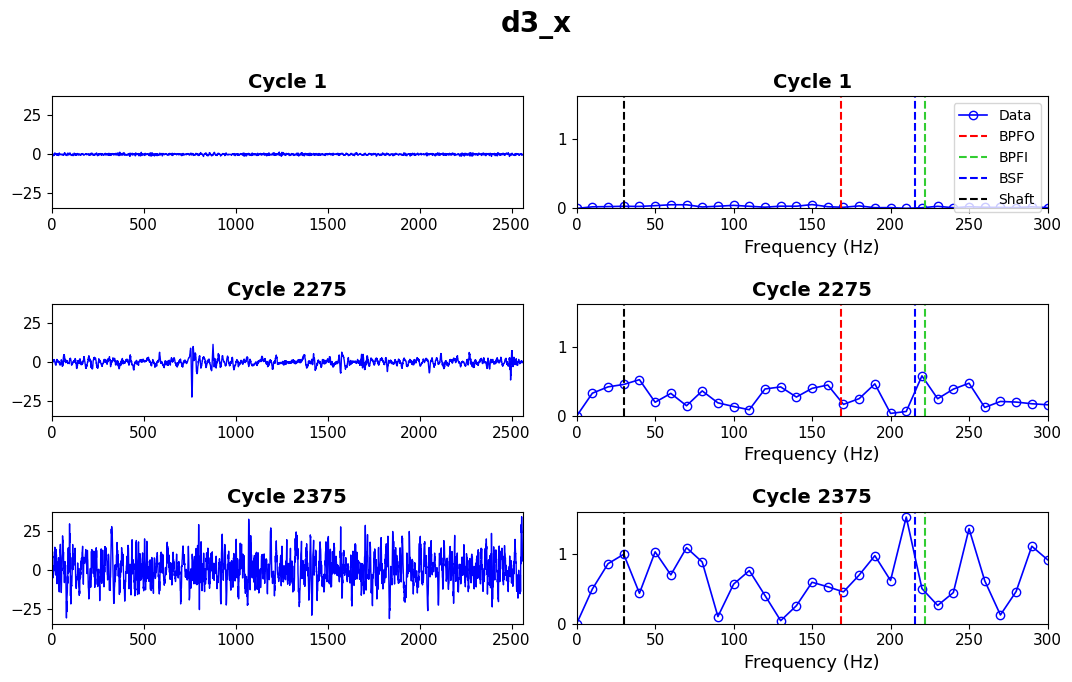

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import hilbert

# ============================================================
# User settings
# (fs, fr, bff, fault_freqs, cutoff are already computed from
#  info.mat in the "Read IMS bearing data" section above)
# ============================================================

# Pick 3 representative cycles regardless of dataset: the first cycle,
# a cycle shortly before the end, and the last cycle.
n_cycle = xall.shape[1]
cycles_to_plot = [1, max(1, n_cycle - 100), n_cycle]

# characteristic frequencies (BPFO, BPFI, FTF, BSF[2x]) in Hz
faultfreq = fault_freqs

# ============================================================
# Helper: single-sided FFT
# ============================================================
# Input : x (signal), fs (sampling frequency)
# Output: freq (frequency axis), fft_mag (magnitude spectrum)
def single_sided_fft(x, fs):
    x = np.asarray(x).flatten()
    N = len(x)
    X = np.abs(np.fft.rfft(x)) * 2 / N
    f = np.fft.rfftfreq(N, d=1/fs)
    return f, X

# ============================================================
# Pre-compute processed signals for selected cycles
# ============================================================
raw_list = []
fft_list = []

# Toggle these to try different processing combinations
# (raw->envelope, AR->envelope, SK->envelope, AR->SK->envelope).
# AR order is searched fresh each time (up to AR_MAX_ORDER) since
# only a few cycles are processed here - see get_envelope() in the
# "Settings and Utilities" section at the top of this notebook.
USE_AR = False
USE_SK = False
AR_MAX_ORDER = 30

for cyc in cycles_to_plot:
    idx = cyc - 1   # Python index
    x = xall[:, idx].flatten()

    env = get_envelope(x, fs, use_ar=USE_AR, use_sk=USE_SK,
                        ar_search=True, ar_max_order=AR_MAX_ORDER)

    f, X = single_sided_fft(env, fs)

    raw_list.append(x)
    fft_list.append((f, X))

# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(3, 2, figsize=(11, 7))
fig.suptitle(var_name, fontsize=20, fontweight='bold')
plt.subplots_adjust(hspace=0.75, wspace=0.35)

# Dynamic x-axis range for the envelope FFT: wide enough to comfortably
# show BPFO/BPFI/BSF (and their harmonics) for whichever bearing/dataset
# is loaded, instead of a fixed 350 Hz that only happens to work for
# the datasets seen so far.
fmax_plot = int(np.ceil(1.3 * np.max(fault_freqs) / 50) * 50)

common_ymax = 1.05 * np.max([
    np.max(X[(f <= fmax_plot) & (f > 1)]) for f, X in fft_list
])

fft_ymax = common_ymax

# Dynamic y-axis range for the raw signal, shared across all plotted
# cycles so the 3 cycles remain visually comparable (works for any
# dataset's amplitude scale, not just IMS).
raw_min = min(np.min(x) for x in raw_list)
raw_max = max(np.max(x) for x in raw_list)
raw_pad = 0.05 * (raw_max - raw_min + 1e-12)

for i, cyc in enumerate(cycles_to_plot):
    # -------------------------
    # Left: raw signal
    # -------------------------
    ax1 = axes[i, 0]
    x = raw_list[i]
    n = len(x)

    ax1.plot(np.arange(n), x, 'b', linewidth=1)
    ax1.set_title(f'Cycle {cyc}', fontsize=14, weight='bold')
    ax1.set_xlim(0, n)
    ax1.set_ylim(raw_min - raw_pad, raw_max + raw_pad)
    ax1.tick_params(labelsize=11)

    # -------------------------
    # Right: envelope FFT
    # -------------------------
    ax2 = axes[i, 1]
    f, X = fft_list[i]
    idxf = f <= fmax_plot

    ax2.plot(f[idxf], X[idxf], 'bo-', markersize=6, markerfacecolor='none',
             linewidth=1.2, label='Data')

    # vertical lines
    l1 = ax2.axvline(faultfreq[0], c='r', linestyle='--', linewidth=1.5, label='BPFO')
    l2 = ax2.axvline(faultfreq[1], c='limegreen', linestyle='--', linewidth=1.5, label='BPFI')
    l3 = ax2.axvline(faultfreq[3], c='b', linestyle='--', linewidth=1.5, label='BSF')
    l4 = ax2.axvline(fr, c='k', linestyle='--', linewidth=1.5, label='Shaft')

    ax2.set_title(f'Cycle {cyc}', fontsize=14, weight='bold')
    ax2.set_xlim(0, fmax_plot)

    ax2.set_ylim(0, fft_ymax)
    ax2.set_xlabel('Frequency (Hz)', fontsize=13)
    ax2.tick_params(labelsize=11)

    if i == 0:
        ax2.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()


### Animation

Selected cycle indices = [22, 1075, 1612, 1935, 1956, 1978, 2000, 2021, 2042, 2064, 2086, 2107, 2128]


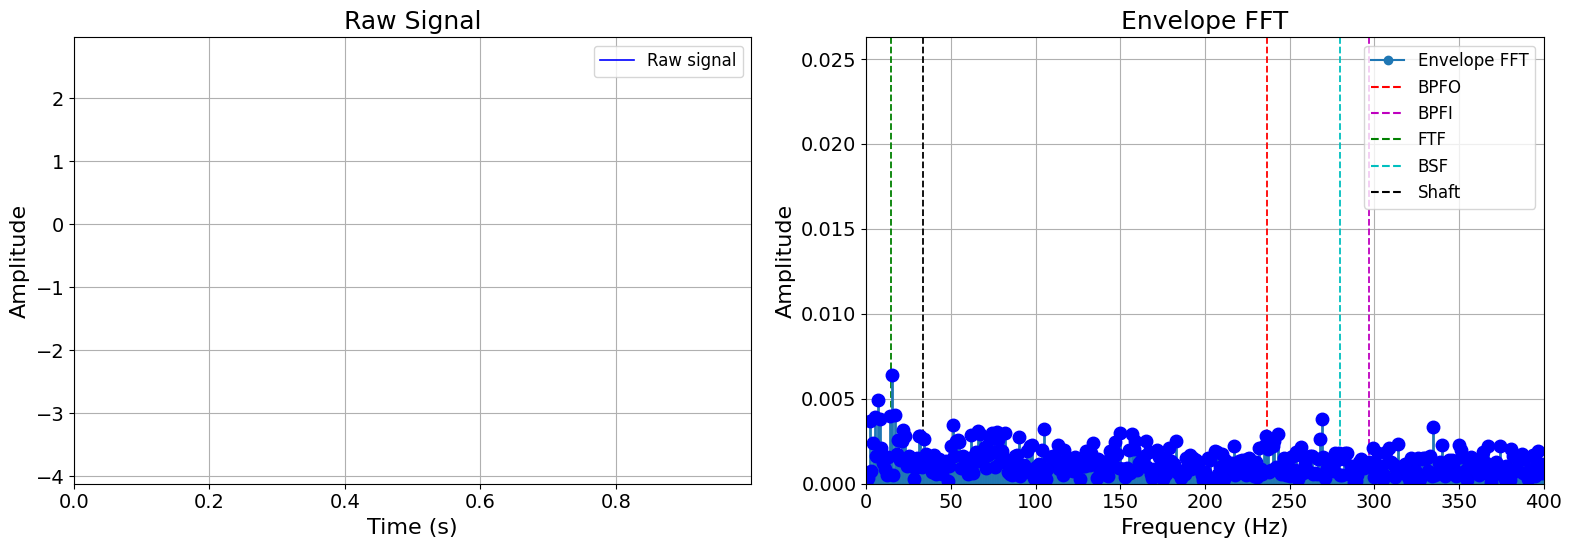

Saved: /content/drive/MyDrive/PHM Practice/Datasets/Bearing_IMS/IMS_1st_ch5_raw_envfft_animation.gif


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.signal import hilbert
from scipy.io import loadmat
import os

BPFO  = fault_freqs[0]
BPFI  = fault_freqs[1]
FTF   = fault_freqs[2]
BSF   = fault_freqs[3]   # spectrum-ready value from info.mat (already 2x raw formula)
SHAFT = fr

# pct_list = [1, 20, 40, 60, 80, 90, 92, 94, 96, 98, 99]
pct_list = [1, 50, 75, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]

# Dynamic envelope FFT x-axis range: wide enough to comfortably show
# BPFO/BPFI/BSF for whichever bearing/dataset is loaded, instead of a
# fixed 350 Hz that only happens to work for the datasets seen so far.
fmax_plot = int(np.ceil(1.3 * np.max(fault_freqs) / 50) * 50)

# ============================================================
# SELECT CYCLES BY PERCENTAGE
# ============================================================
Ns, Nc = xall.shape
t = np.arange(Ns) / fs
freq = np.fft.rfftfreq(Ns, d=1/fs)

cycle_idx = [max(0, min(Nc-1, round((p/100)*(Nc-1)))) for p in pct_list]

# remove duplicates
cycle_idx_unique = []
pct_unique = []
for p, idx in zip(pct_list, cycle_idx):
    if idx not in cycle_idx_unique:
        cycle_idx_unique.append(idx)
        pct_unique.append(p)

cycle_idx = cycle_idx_unique
pct_list = pct_unique

print('Selected cycle indices =', cycle_idx)

# ============================================================
# PRECOMPUTE RAW + ENVELOPE FFT
# ============================================================
raw_list = []
envfft_list = []

USE_AR = False
USE_SK = False

for idx in cycle_idx:
    x = xall[:, idx].flatten()

    # get_envelope is defined in "Settings and Utilities"
    env = get_envelope(x, fs, use_ar=USE_AR, use_sk=USE_SK)

    ENV = np.abs(np.fft.rfft(env)) * 2 / Ns

    raw_list.append(x)
    envfft_list.append(ENV)

# ============================================================
# COMMON AXIS LIMITS
# ============================================================
raw_min = min(np.min(x) for x in raw_list)
raw_max = max(np.max(x) for x in raw_list)
raw_pad = 0.05 * (raw_max - raw_min + 1e-12)

envfft_max = max(np.max(X[1:]) for X in envfft_list)   # exclude DC
envfft_ymax = 1.05 * envfft_max

fft_ymax = envfft_ymax

# ============================================================
# STYLE
# ============================================================
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
title_text = fig.suptitle('', fontsize=20)

# -------------------------
# Left: raw signal
# -------------------------
line_raw, = ax1.plot([], [],'b', lw=1.2, label='Raw signal')

ax1.set_xlim(t[0], t[-1])
ax1.set_ylim(raw_min - raw_pad, raw_max + raw_pad)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.set_title('Raw Signal')
ax1.grid(True)
ax1.legend(loc='upper right')

# cycle text inside left plot
cycle_text_left = ax1.text(
    0.02, 0.92, '', transform=ax1.transAxes,
    fontsize=15, verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
)

# -------------------------
# Right: envelope FFT stem
# -------------------------
ax2.set_xlim(0, fmax_plot)
ax2.set_ylim(0, fft_ymax)
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Amplitude')
ax2.set_title('Envelope FFT')
ax2.grid(True)

# frequency lines
ax2.axvline(BPFO,  color='r', linestyle='--', linewidth=1.3, label='BPFO')
ax2.axvline(BPFI,  color='m', linestyle='--', linewidth=1.3, label='BPFI')
ax2.axvline(FTF,   color='g', linestyle='--', linewidth=1.3, label='FTF')
ax2.axvline(BSF,   color='c', linestyle='--', linewidth=1.3, label='BSF')
ax2.axvline(SHAFT, color='k', linestyle='--', linewidth=1.3, label='Shaft')

# initial stem
mask = freq <= fmax_plot
freq_plot = freq[mask]
X0 = envfft_list[0][mask]
stem_marker_size = 9

markerline, stemlines, baseline = ax2.stem(
    freq_plot, X0,  markerfmt='bo', basefmt=' '
)
plt.setp(markerline, markersize=stem_marker_size,
)
plt.setp(stemlines, linewidth=2.0)

# legend
from matplotlib.lines import Line2D
fft_handle   = Line2D([0], [0], color='C0', marker='o', linestyle='-', label='Envelope FFT')
bpfo_handle  = Line2D([0], [0], color='r', linestyle='--', label='BPFO')
bpfi_handle  = Line2D([0], [0], color='m', linestyle='--', label='BPFI')
ftf_handle   = Line2D([0], [0], color='g', linestyle='--', label='FTF')
bsf_handle   = Line2D([0], [0], color='c', linestyle='--', label='BSF')
shaft_handle = Line2D([0], [0], color='k', linestyle='--', label='Shaft')

ax2.legend(handles=[fft_handle, bpfo_handle, bpfi_handle, ftf_handle, bsf_handle, shaft_handle],
           loc='upper right')

# cycle text inside right plot
cycle_text_right = ax2.text(
    0.02, 0.92, '', transform=ax2.transAxes,
    fontsize=15, verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
)

# ============================================================
# ANIMATION
# ============================================================
# Input : none (uses enclosing scope variables)
# Output: initializes the animation frame (matplotlib FuncAnimation)
def init():
    line_raw.set_data([], [])
    cycle_text_left.set_text('')
    cycle_text_right.set_text('')
    title_text.set_text('')
    return line_raw, markerline, stemlines, cycle_text_left, cycle_text_right, title_text

# Input : frame index (from FuncAnimation)
# Output: updates the animation frame (matplotlib FuncAnimation)
def update(frame):
    global markerline, stemlines, baseline

    x = raw_list[frame]
    X = envfft_list[frame][mask]
    pct = pct_list[frame]
    idx = cycle_idx[frame]

    # left plot
    line_raw.set_data(t, x)

    # right plot: remove previous stem and redraw
    markerline.remove()
    try:
        stemlines.remove()
    except:
        for st in stemlines:
            st.remove()

    markerline, stemlines, baseline = ax2.stem(
        freq_plot, X, linefmt='C0-', markerfmt='C0o', basefmt=' '
    )
    plt.setp(markerline, markersize=stem_marker_size)
    plt.setp(stemlines, linewidth=1.0)

    # title
    title_text.set_text(f'{var_name} | {pct}% of life')

    # cycle text inside each plot
    cycle_msg = f'Cycle {idx+1} / {Nc}'
    cycle_text_left.set_text(cycle_msg)
    cycle_text_right.set_text(cycle_msg)

    return line_raw, markerline, stemlines, cycle_text_left, cycle_text_right, title_text

anim = FuncAnimation(
    fig,
    update,
    frames=len(pct_list),
    init_func=init,
    interval=1200,
    blit=False,
    repeat=True
)
plt.tight_layout()
plt.show()

# ============================================================
# SAVE GIF
# ============================================================
# apply signal processing conditions(raw / ar / sk / ar_sk)
proc_tag = '_'.join(t for t, on in [('ar', USE_AR), ('sk', USE_SK)] if on) or 'raw'

# save in the corresponding dataset folder
save_path = str(base_path / f'{var_name}_{proc_tag}_envfft_animation.gif')
anim.save(save_path, writer=PillowWriter(fps=1))
print('Saved:', save_path)


### Features over entire cycles

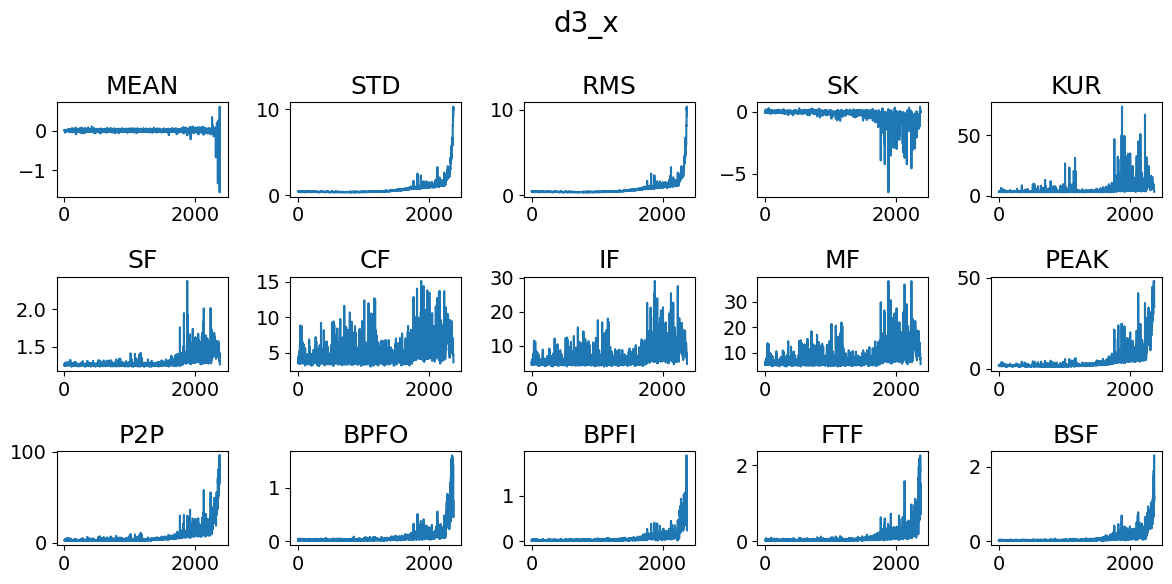

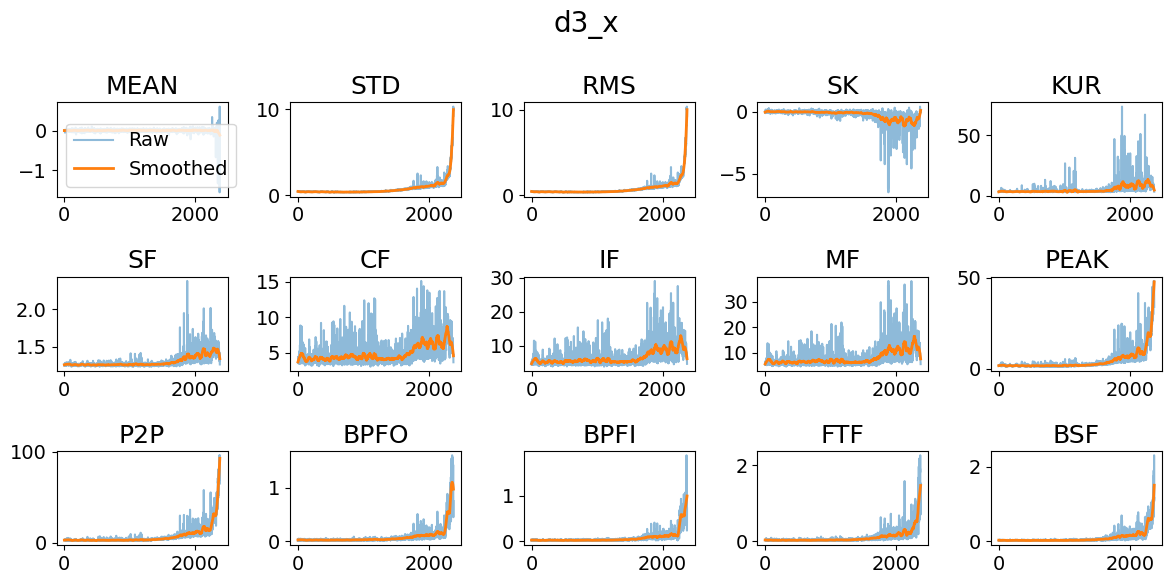

In [12]:
# (fs, fr, bff, fault_freqs, cutoff are already computed from
#  info.mat in the "Read IMS bearing data" section above)
N_cycle = xall.shape[1]
features = []

# AR filtering is left OFF by default here: with hundreds/thousands
# of cycles, searching the AR order fresh for every single cycle
# (as done in "feature at specific cycles") would be far too slow,
# and the search-vs-fixed-order comparison earlier showed most of
# the whitening benefit is already captured without AR filtering.
# If AR filtering is needed for a specific dataset, determine a
# single fixed order once (e.g. from the last, most-degraded cycle,
# using ar_search=True there) and reuse that fixed order for every
# cycle in this loop via ar_order=<that value>.
USE_AR = False
USE_SK = False
AR_ORDER = 30   # only used if USE_AR=True

for ix_file in range(N_cycle):
    x = xall[:, ix_file]   # one cycle signal, shape = (20480,)

    # Extract time-domain features
    tmp1, fn_time = timefeature(x)

    # Envelope, with optional AR/SK filtering
    # (get_envelope is defined in the "Settings and Utilities"
    #  section at the top of this notebook)
    xe = get_envelope(x, fs, use_ar=USE_AR, use_sk=USE_SK, ar_order=AR_ORDER)

    # Extract bearing-related features
    tmp2, fn_bearing = bear_feat(xe, fs, fault_freqs, cutoff)

    # Concatenate features
    features.append(np.hstack([tmp1, tmp2]))

features = np.array(features)
feature_name = fn_time + fn_bearing

plt.figure(figsize=(12, 6))

for i in range(features.shape[1]):
    plt.subplot(3, 5, i + 1)
    plt.plot(features[:, i])
    plt.title(feature_name[i])

plt.suptitle(var_name, fontsize=20)
plt.tight_layout()
plt.show()

# ----------------------------------------
# Smooth features -> features_smth
# ----------------------------------------
from scipy.signal import savgol_filter

n_cycle, n_feat = features.shape
features_smth = np.zeros_like(features)

for i in range(n_feat):
    y = features[:, i]

    win = int(n_cycle * 0.03)
    if win < 11:
        win = 11

    if win % 2 == 0:
        win += 1

    if win >= n_cycle:
        if n_cycle % 2 == 0:
            win = n_cycle - 1
        else:
            win = n_cycle

    if win < 5:
        features_smth[:, i] = y
    else:
        features_smth[:, i] = savgol_filter(y, window_length=win, polyorder=2)

plt.figure(figsize=(12, 6))

for i in range(features.shape[1]):
    plt.subplot(3, 5, i + 1)
    plt.plot(features[:, i], label='Raw', alpha=0.5)
    plt.plot(features_smth[:, i], label='Smoothed', linewidth=2)
    plt.title(feature_name[i])
    if i == 0:
        plt.legend()

plt.suptitle(var_name, fontsize=20)
plt.tight_layout()
plt.show()




In [13]:
# save features over cycles into file.
import os
import pandas as pd

save_dir = base_path
os.makedirs(save_dir, exist_ok=True)

df_output = pd.DataFrame({'Cycle': np.arange(1, N_cycle + 1)})

for i, name in enumerate(feature_name):
    df_output[f'{name}_raw'] = features[:, i]
    df_output[f'{name}_smoothed'] = features_smth[:, i]

save_path = os.path.join(save_dir, f'{var_name}_features.csv')
df_output.to_csv(save_path, index=False)

print(f'Saved to: {save_path}')

Saved to: /content/drive/MyDrive/PHM Practice/Datasets/Bearing_FEMTO/d3_x_features.csv


## Features selection

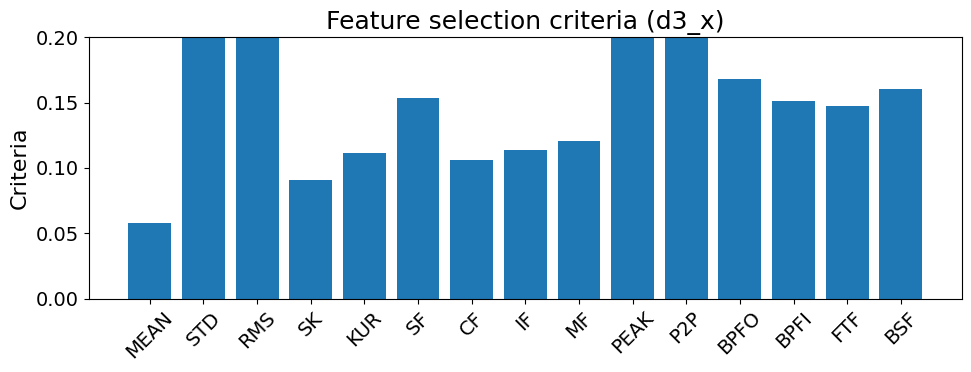

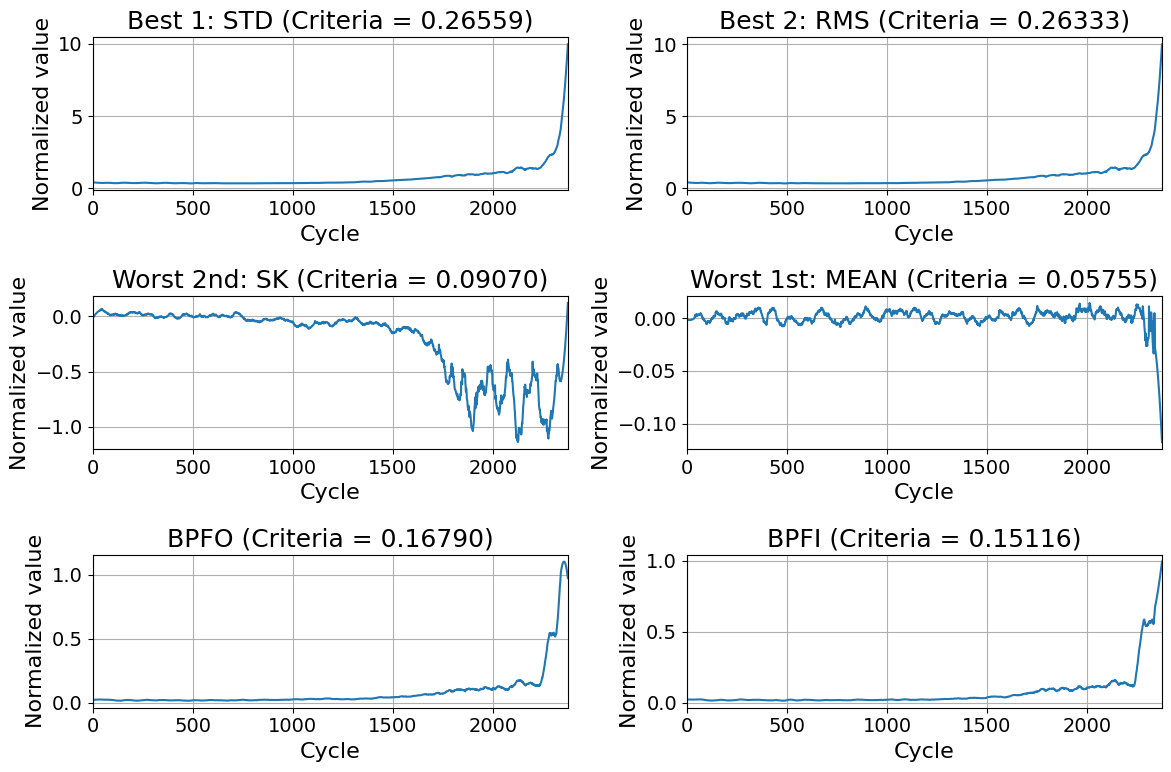

In [14]:
# prognosis metrics

import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Feature selection for cabstone_prognosis
N = features.shape[0]

cycle = np.arange(0, N)
w = np.asmatrix([0.9, 0.05, 0.05])

# Monotonicity (sign based)
mon = np.abs(np.sum(np.diff(features_smth, axis=0)>0, axis=0)-np.sum(np.diff(features_smth, axis=0)<0, axis=0))/(N-1)

# Monotonicity (spearman based)
tre = np.abs(spearmanr(cycle, features_smth))[0,1:,0]

# Robustness
eps = 1e-12
rob = np.zeros(features_smth.shape[1])

for ix in range(features_smth.shape[1]):
    relative_error = (features[:, ix] - features_smth[:, ix]) / (np.abs(features[:, ix]) + eps)
    rob[ix] = np.mean(np.exp(-np.abs(relative_error)))

# Feature selection criteria
cri = np.ravel(np.c_[mon, tre, rob] * w.T)
ix = np.argsort(cri)[::-1]
cri_sort = cri[ix]

# Criteria bar plot
plt.figure(figsize=(10, 4))
plt.bar(range(15), cri)
plt.title(f'Feature selection criteria ({var_name})')
plt.ylabel('Criteria')
plt.xticks(range(15), feature_name, rotation=45)
plt.ylim(0, 0.2)
plt.tight_layout()
plt.show()

# Indices
best_idx_1 = ix[0]
best_idx_2 = ix[1]
worst_idx_1 = ix[-2]
worst_idx_2 = ix[-1]
bpfo_idx = feature_name.index('BPFO')
bpfi_idx = feature_name.index('BPFI')

selected_idx = [best_idx_1, best_idx_2, worst_idx_1, worst_idx_2, bpfo_idx, bpfi_idx]
selected_titles = [
    f'Best 1: {feature_name[best_idx_1]} (Criteria = {cri[best_idx_1]:.5f})',
    f'Best 2: {feature_name[best_idx_2]} (Criteria = {cri[best_idx_2]:.5f})',
    f'Worst 2nd: {feature_name[worst_idx_1]} (Criteria = {cri[worst_idx_1]:.5f})',
    f'Worst 1st: {feature_name[worst_idx_2]} (Criteria = {cri[worst_idx_2]:.5f})',
    f'BPFO (Criteria = {cri[bpfo_idx]:.5f})',
    f'BPFI (Criteria = {cri[bpfi_idx]:.5f})'
]

xmax_cycle = cycle[-1]

plt.figure(figsize=(12, 8))
for i, idx_sel in enumerate(selected_idx):
    plt.subplot(3, 2, i + 1)
    plt.plot(cycle, features_smth[:, idx_sel], linewidth=1.5)
    plt.xlabel('Cycle')
    plt.ylabel('Normalized value')
    plt.xlim(cycle[0], xmax_cycle)
    plt.title(selected_titles[i])
    plt.grid(True)

plt.tight_layout()
plt.show()